In [2]:
CSV="./TAD/pred_results_25kbp_ctx512.csv"

Wrote: ./TAD/pred_vs_true.tsv
Saved figure: ./TAD/pred_vs_true_scatter.png
Pearson=0.4325  Spearman=0.4187


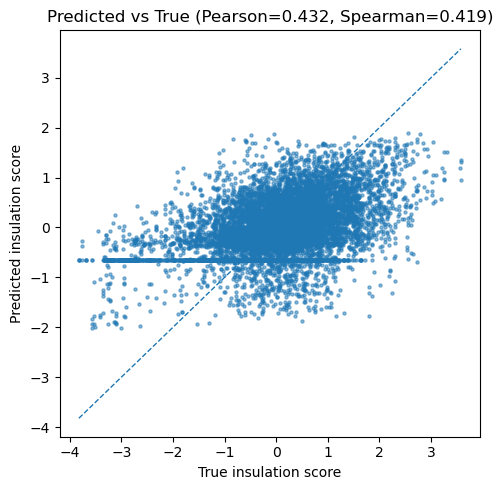

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# CSV = "pred_results.csv"   # first col = true, second = pred
OUT_TSV = "./TAD/pred_vs_true.tsv"
OUT_PNG = "./TAD/pred_vs_true_scatter.png"

# 1) read CSV with header (e.g., "TPM" etc.)
df = pd.read_csv(CSV)  # keeps header
# take first two columns explicitly
true = pd.to_numeric(df.iloc[:,0], errors="coerce")
pred = pd.to_numeric(df.iloc[:,1], errors="coerce")
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# 2) write a clean 2-col TSV (no header)
pd.DataFrame({"true": true, "pred": pred}).to_csv(OUT_TSV, sep="\t", index=False, header=False)

# 3) correlations
pear, _ = pearsonr(true, pred)
spear, _ = spearmanr(true, pred)

# 4) scatter plot
plt.figure(figsize=(5,5))
plt.scatter(true, pred, s=5, alpha=0.5)
# y = x reference
mn, mx = float(np.min(true)), float(np.max(true))
plt.plot([mn, mx], [mn, mx], "--", lw=1)

plt.title(f"Predicted vs True (Pearson={pear:.3f}, Spearman={spear:.3f})")
plt.xlabel("True insulation score")
plt.ylabel("Predicted insulation score")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
print(f"Wrote: {OUT_TSV}\nSaved figure: {OUT_PNG}\nPearson={pear:.4f}  Spearman={spear:.4f}")

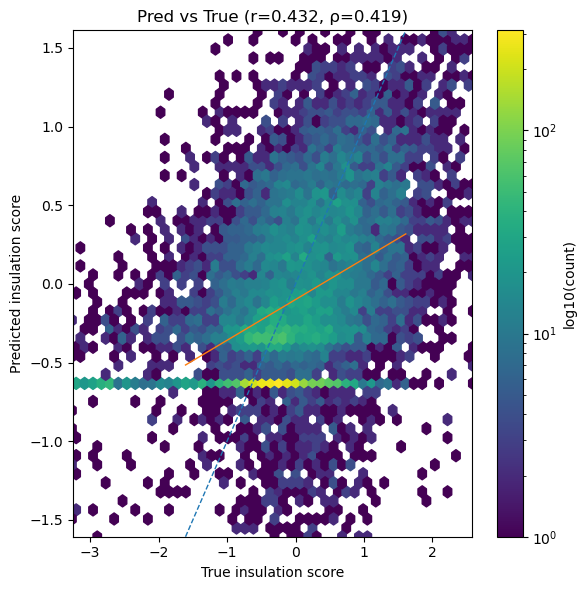

In [5]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

pear, _ = pearsonr(true, pred)
spear, _ = spearmanr(true, pred)
p = np.percentile(true, [0.5, 99.5]); q = np.percentile(pred, [0.5, 99.5])

plt.figure(figsize=(6,6))
hb = plt.hexbin(true, pred, gridsize=60, bins='log')
plt.colorbar(hb, label='log10(count)')

# y = x
mn, mx = max(p[0], q[0]), min(p[1], q[1])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1)

# best-fit line
slope, intercept, *_ = linregress(true, pred)
xfit = np.linspace(mn, mx, 100)
plt.plot(xfit, slope*xfit + intercept, linewidth=1)

plt.xlim(p); plt.ylim(q)
plt.title(f"Pred vs True (r={pear:.3f}, ρ={spear:.3f})")
plt.xlabel("True insulation score"); plt.ylabel("Predicted insulation score")
plt.tight_layout(); plt.show()


In [6]:
# 1) Is there a spike around -0.8?
vals, cnts = np.unique(np.round(pred, 2), return_counts=True)
top = sorted(zip(cnts, vals), reverse=True)[:10]
print("Top prediction modes (count, value):", top)

# 2) Do the “flat” predictions come from certain chromosomes or token lengths?
flat_mask = (pred > -0.82) & (pred < -0.78)
print("Flat %:", flat_mask.mean())
# if you kept meta: chrom[flat_mask].value_counts() ; tok_len[flat_mask].describe()

# 3) Calibration check
print("true mean/std:", np.mean(true), np.std(true))
print("pred mean/std:", np.mean(pred), np.std(pred))


Top prediction modes (count, value): [(np.int64(2717), np.float64(-0.64)), (np.int64(137), np.float64(-0.32)), (np.int64(125), np.float64(-0.34)), (np.int64(122), np.float64(-0.35)), (np.int64(115), np.float64(-0.31)), (np.int64(115), np.float64(-0.33)), (np.int64(111), np.float64(-0.3)), (np.int64(110), np.float64(-0.36)), (np.int64(99), np.float64(-0.29)), (np.int64(88), np.float64(-0.26))]
Flat %: 0.0023224653863331843
true mean/std: 0.0028302683445837456 0.9879564234431686
pred mean/std: -0.09897249952953724 0.5913029684689802


Saved: pred_vs_true_hexbin.png, residuals_hexbin.png


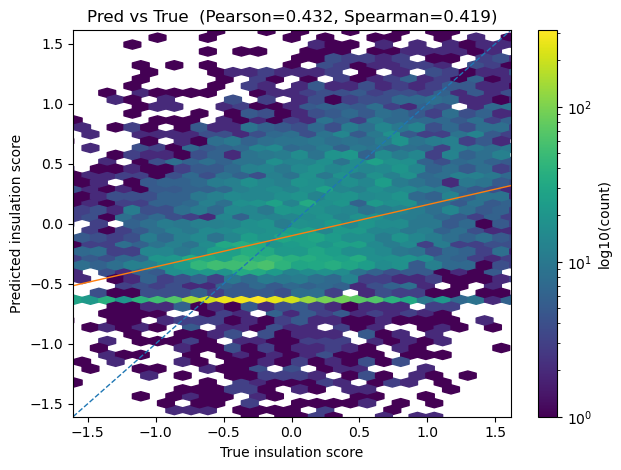

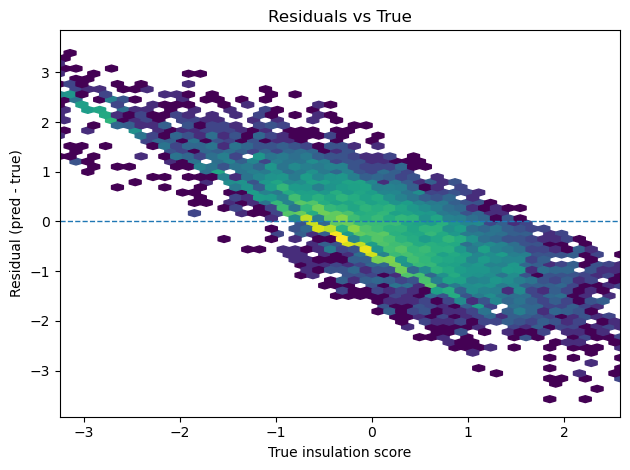

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

df = pd.read_csv(CSV)   # first col true, second pred
true = pd.to_numeric(df.iloc[:,0], errors="coerce")
pred = pd.to_numeric(df.iloc[:,1], errors="coerce")
m = np.isfinite(true) & np.isfinite(pred)
true, pred = true[m], pred[m]

# correlations
r, _ = pearsonr(true, pred)
rho, _ = spearmanr(true, pred)

# percentiles to clip axes (reduces outlier stretch)
tx = np.percentile(true, [0.5, 99.5])
px = np.percentile(pred, [0.5, 99.5])
mn, mx = max(tx[0], px[0]), min(tx[1], px[1])

# best-fit line
slope, intercept, *_ = linregress(true, pred)
xfit = np.linspace(mn, mx, 100)

# ---- density scatter (hexbin) ----
plt.figure()
hb = plt.hexbin(true, pred, gridsize=60, bins="log")
plt.colorbar(hb, label="log10(count)")
plt.plot([mn, mx], [mn, mx], "--", lw=1)                 # y=x
plt.plot(xfit, slope*xfit + intercept, lw=1)             # best-fit
plt.xlim(mn, mx); plt.ylim(mn, mx)
plt.xlabel("True insulation score")
plt.ylabel("Predicted insulation score")
plt.title(f"Pred vs True  (Pearson={r:.3f}, Spearman={rho:.3f})")
plt.tight_layout(); plt.savefig("pred_vs_true_hexbin.png", dpi=200)

# ---- residuals (shows the horizontal band clearly) ----
res = pred - true
plt.figure()
plt.hexbin(true, res, gridsize=60, bins="log")
plt.axhline(0, ls="--", lw=1)
plt.xlim(tx); plt.xlabel("True insulation score")
plt.ylabel("Residual (pred - true)")
plt.title("Residuals vs True")
plt.tight_layout(); plt.savefig("residuals_hexbin.png", dpi=200)

print("Saved: pred_vs_true_hexbin.png, residuals_hexbin.png")


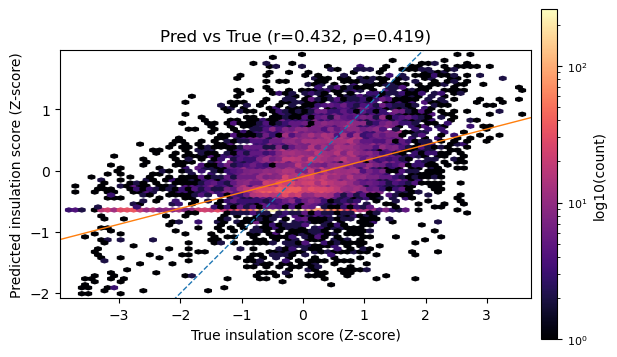

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# CSV = "pred_results.csv"   # col0=true, col1=pred
CMAP = "magma"             # try: "plasma", "inferno", "turbo", "viridis"

df = pd.read_csv(CSV)
true = pd.to_numeric(df.iloc[:,0], errors="coerce")
pred = pd.to_numeric(df.iloc[:,1], errors="coerce")
m = np.isfinite(true) & np.isfinite(pred)
true, pred = true[m], pred[m]

# stats
r, _ = pearsonr(true, pred)
rho, _ = spearmanr(true, pred)
slope, intercept, *_ = linregress(true, pred)

# full-range limits (+ small visual margin)
xmin, xmax = float(true.min()), float(true.max())
ymin, ymax = float(pred.min()), float(pred.max())
xr = xmax - xmin; yr = ymax - ymin
xmin -= 0.02 * xr; xmax += 0.02 * xr
ymin -= 0.02 * yr; ymax += 0.02 * yr

# # ---- Pred vs True density ----
fig, ax = plt.subplots(figsize=(6.2,6), constrained_layout=True)

hb = ax.hexbin(true, pred, gridsize=70, bins="log", cmap=CMAP, mincnt=1)
cbar = fig.colorbar(hb, ax=ax, label="log10(count)", fraction=0.035, pad=0.02)  # ↓ width & gap
cbar.ax.tick_params(labelsize=8)

lo, hi = min(xmin, ymin), max(xmax, ymax)
ax.plot([lo, hi], [lo, hi], "--", lw=1)
xfit = np.linspace(lo, hi, 100)
ax.plot(xfit, slope*xfit + intercept, lw=1)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel("True insulation score (Z-score)")
ax.set_ylabel("Predicted insulation score (Z-score)")
ax.set_title(f"Pred vs True (r={r:.3f}, ρ={rho:.3f})")
fig.savefig("pred_vs_true_hexbin_full.png", dpi=220)
# plt.figure(figsize=(6.2,6))
# hb = plt.hexbin(true, pred, gridsize=70, bins="log", cmap=CMAP, mincnt=1)
# plt.colorbar(hb, label="log10(count)")
# # y=x
# lo, hi = min(xmin, ymin), max(xmax, ymax)
# plt.plot([lo, hi], [lo, hi], "--", lw=1)
# # best-fit line
# xfit = np.linspace(lo, hi, 100)
# plt.plot(xfit, slope*xfit + intercept, lw=1)

# plt.gca().set_aspect("equal", adjustable="box")
# plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
# plt.xlabel("True insulation score (Z-score)")
# plt.ylabel("Predicted insulation score (Z-score)")
# plt.title(f"Pred vs True (r={r:.3f}, ρ={rho:.3f})")
# plt.margins(0.01)
# plt.tight_layout()
# plt.savefig("pred_vs_true_hexbin_full.png", dpi=220)


# # ---- Residuals density (full range) ----
# res = pred - true
# rymin, rymax = float(res.min()), float(res.max())
# ry = rymax - rymin
# rymin -= 0.02 * ry; rymax += 0.02 * ry

# plt.figure(figsize=(6.2,3.8))
# hb2 = plt.hexbin(true, res, gridsize=70, bins="log", cmap=CMAP, mincnt=1)
# plt.colorbar(hb2, label="log10(count)")
# plt.axhline(0, ls="--", lw=1)
# plt.xlim(xmin, xmax); plt.ylim(rymin, rymax)
# plt.xlabel("True insulation score")
# plt.ylabel("Residual (pred - true)")
# plt.title("Residuals vs True")
# plt.margins(0.01)
# plt.tight_layout()
# plt.savefig("residuals_hexbin_full.png", dpi=220)

# print("Saved: pred_vs_true_hexbin_full.png, residuals_hexbin_full.png")


In [44]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

def plot_pred_vs_true(path, cmap="magma", gridsize=70, clip01=False,
                      xlabel="True score", ylabel="Predicted score",
                      outfile="pred_vs_true_hexbin.png", show=True):
    df = pd.read_csv(path)
    true = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    pred = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    m = np.isfinite(true) & np.isfinite(pred)
    true, pred = true[m], pred[m]

    # Stats
    r, _ = pearsonr(true, pred)
    rho, _ = spearmanr(true, pred)
    slope, intercept, *_ = linregress(true, pred)

    xmin, xmax = float(true.min()), float(true.max())
    ymin, ymax = float(pred.min()), float(pred.max())
    if clip01:
        xmin, xmax = 0, 1; ymin, ymax = 0, 1
    lo, hi = min(xmin, ymin), max(xmax, ymax)

    fig, ax = plt.subplots(figsize=(6.2,6), constrained_layout=True)
    hb = ax.hexbin(true, pred, gridsize=gridsize, bins="log", cmap=cmap, mincnt=1)
    fig.colorbar(hb, ax=ax, label="log10(count)", fraction=0.035, pad=0.02)
    ax.plot([lo, hi], [lo, hi], "--", lw=1)
    xfit = np.linspace(lo, hi, 200)
    ax.plot(xfit, slope*xfit + intercept, lw=1)
    ax.set_aspect("equal", adjustable="box")
    # ax.set_xlim(xmin, xmax+0.2); ax.set_ylim(ymin, ymax+0.2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f"Pred vs True (r={r:.3f}, ρ={rho:.3f})")
    fig.savefig(outfile, dpi=220)
    if show: plt.show()
    plt.close(fig)
    return {"pearson_r": r, "spearman_r": rho, "slope": slope, "intercept": intercept}


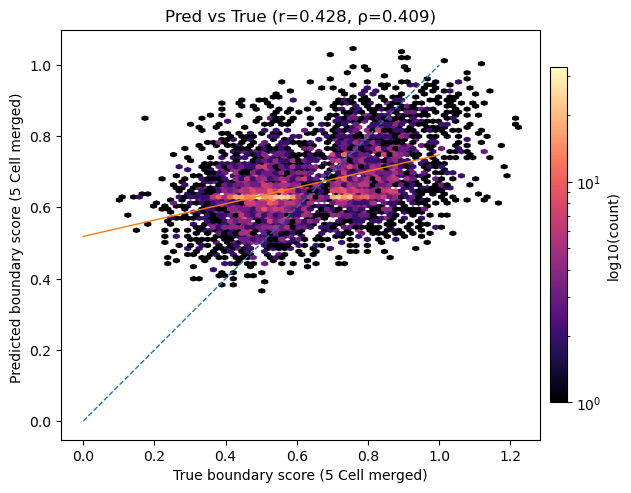

{'pearson_r': np.float64(0.42780263763724735), 'spearman_r': np.float64(0.40888479504969855), 'slope': np.float64(0.22936129653551773), 'intercept': np.float64(0.5186263399626059)}


In [47]:
stats_5cellmerged = plot_pred_vs_true(
    "./TAD/TAD_boundary_ft5cells/regression/25kbp_ctx512/LR3e-5/pred_results.csv",
    xlabel="True boundary score (5 Cell merged)",
    ylabel="Predicted boundary score (5 Cell merged) ",
    clip01=True,
    outfile="pred_vs_true_boundary_score_5cell_merged.png"
)
print(stats_5cellmerged)

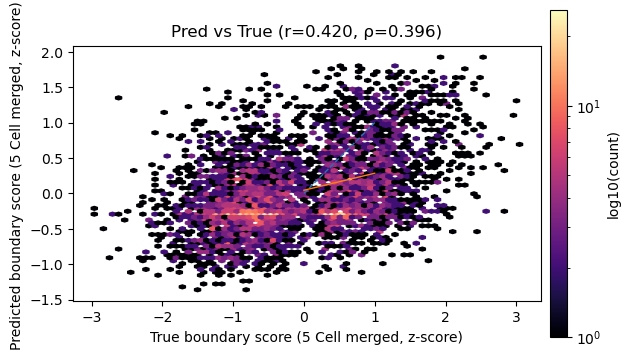

{'pearson_r': np.float64(0.41998452865351477), 'spearman_r': np.float64(0.39585358586461944), 'slope': np.float64(0.24028760353516887), 'intercept': np.float64(0.04454344044801112)}


In [49]:
stats_5cellmerged = plot_pred_vs_true(
    "./TAD/TAD_boundary_ft5cells/regression/25kbp_ctx512_z/LR3e-5/pred_results.csv",
    xlabel="True boundary score (5 Cell merged, z-score)",
    ylabel="Predicted boundary score (5 Cell merged, z-score) ",
    clip01=True,
    outfile="pred_vs_true_boundary_score_5cell_merged.png"
)
print(stats_5cellmerged)

In [28]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

ROOT = Path("./TAD/TAD_boundary/classification")

RE_KBP  = re.compile(r"(\d+)kbp")
RE_CTX  = re.compile(r"ctx(\d+)")
RE_EXCL = re.compile(r"excl(\d+)")
RE_LR   = re.compile(r"^LR([0-9eE\.\-]+)$")

def parse_hparams(config_str: str):
    kbp  = RE_KBP.search(config_str or "")
    ctx  = RE_CTX.search(config_str or "")
    excl = RE_EXCL.search(config_str or "")
    flags = []
    for token in (config_str or "").split("_"):
        if not token: continue
        if RE_KBP.search(token) or RE_CTX.search(token) or RE_EXCL.search(token):
            continue
        flags.append(token)
    return {
        "kbp":  kbp.group(1) if kbp else None,
        "ctx":  ctx.group(1) if ctx else None,
        "excl": excl.group(1) if excl else None,
        "flags": ",".join(flags) if flags else ""
    }

def parse_lr_from_folder(lr_folder: str):
    m = RE_LR.match(lr_folder or "")
    if m:
        try:    return lr_folder, float(m.group(1))
        except: return lr_folder, np.nan
    return lr_folder, np.nan

def safe_float(x):
    try:    return float(x)
    except: return np.nan

rows = []
for f in ROOT.rglob("eval_results.txt"):
    parts = f.parts
    idx = parts.index("classification")
    task   = parts[idx+1] if len(parts)>idx+1 else None
    config = parts[idx+2] if len(parts)>idx+2 else None
    lr_dir = parts[idx+3] if len(parts)>idx+3 else None
    hp = parse_hparams(config)
    lr_label, lr_float = parse_lr_from_folder(lr_dir)

    with f.open() as fh:
        run_id = 0
        for line in fh:
            toks = line.strip().split()
            if len(toks) < 4: 
                continue
            acc, f1, auc = map(safe_float, toks[-3:])
            name_token = " ".join(toks[:-3])
            rows.append({
                "task": task,
                "config": config,
                "lr_folder": lr_label,
                "lr_float": lr_float,
                "kbp": hp["kbp"], "ctx": hp["ctx"], "excl": hp["excl"], "flags": hp["flags"],
                "condition": f"{config} / {lr_label}",
                "name_token": name_token,
                "run_id": run_id,
                "accuracy": acc, "f1": f1, "auc": auc,
                "file": str(f)
            })
            run_id += 1

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(164, 15)


,task,config,lr_folder,lr_float,kbp,ctx,excl,flags,condition,name_token,run_id,accuracy,f1,auc,file
0,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,0,0.594,0.500,0.00,TAD/TAD_boundary/classification/strong_non/25k...
1,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,1,0.602,0.565,0.43,TAD/TAD_boundary/classification/strong_non/25k...
2,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,2,0.594,0.500,0.00,TAD/TAD_boundary/classification/strong_non/25k...
3,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,3,0.594,0.500,0.00,TAD/TAD_boundary/classification/strong_non/25k...
4,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,4,0.594,0.500,0.00,TAD/TAD_boundary/classification/strong_non/25k...


In [31]:
metrics = ["accuracy","f1","auc"]
summary = (
    df.groupby(["task","condition"])[metrics]
      .agg(["mean","std","count"])
      .reset_index()
)
# Flatten multiindex columns like ('f1','mean') -> 'f1_mean'
summary.columns = ["_".join(c).strip("_") for c in summary.columns.to_flat_index()]

# sanity check
print(summary.columns.tolist())
summary.head()


['task', 'condition', 'accuracy_mean', 'accuracy_std', 'accuracy_count', 'f1_mean', 'f1_std', 'f1_count', 'auc_mean', 'auc_std', 'auc_count']


,task,condition,accuracy_mean,accuracy_std,accuracy_count,f1_mean,f1_std,f1_count,auc_mean,auc_std,auc_count
0,boundary_nonboundary,25kbp_ctx512 / LR3e-5,0.558381,0.015914,21,0.556667,0.015160,21,0.514095,0.067422,21
1,boundary_nonboundary,25kbp_ctx512_excl2 / LR3e-5,0.552400,0.014901,20,0.554750,0.011973,20,0.537000,0.022909,20
2,strong_non,25kbp_ctx512 / LR1e-4,0.600143,0.007273,14,0.529857,0.032800,14,0.189786,0.210347,14
3,strong_non,25kbp_ctx512 / LR3e-5,0.594250,0.001000,16,0.502563,0.010250,16,0.020563,0.082250,16
4,strong_non,25kbp_ctx512_excl2 / LR1e-4,0.600143,0.007273,14,0.529857,0.032800,14,0.189786,0.210347,14


Saved: figs/boundary_nonboundary_box.png


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


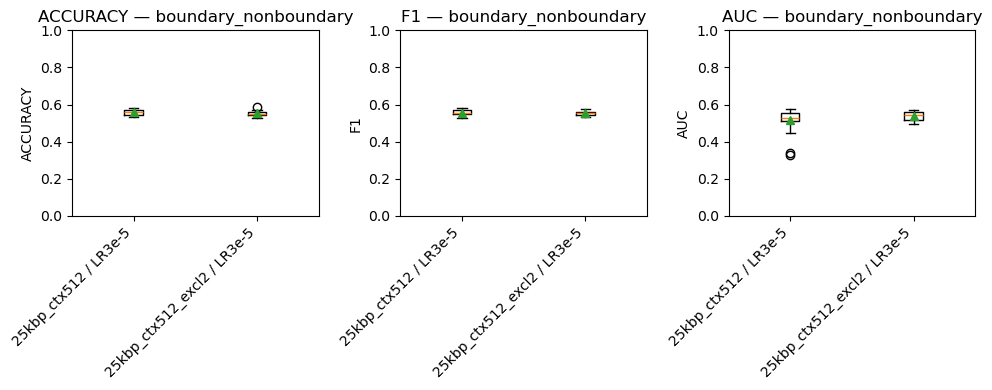

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


Saved: figs/strong_non_box.png


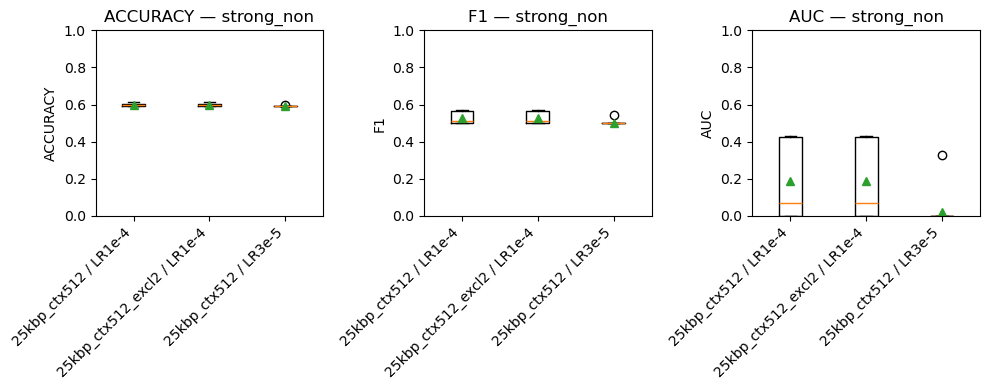

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


Saved: figs/strong_weak_box.png


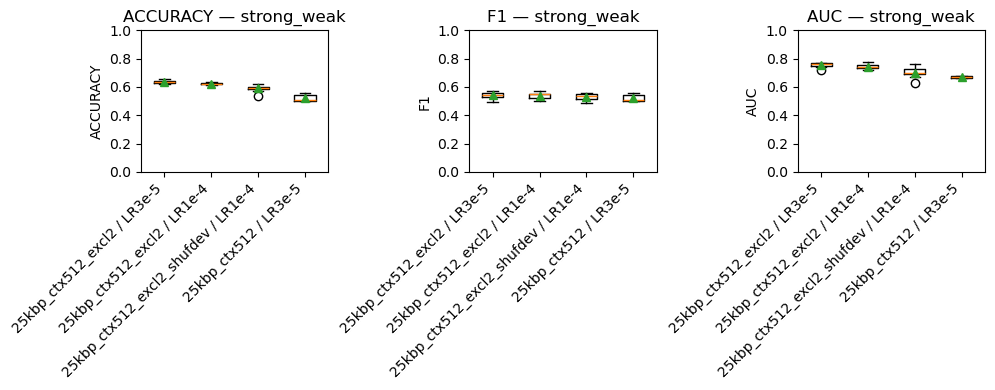

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/2383863173.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


Saved: figs/weak_non_box.png


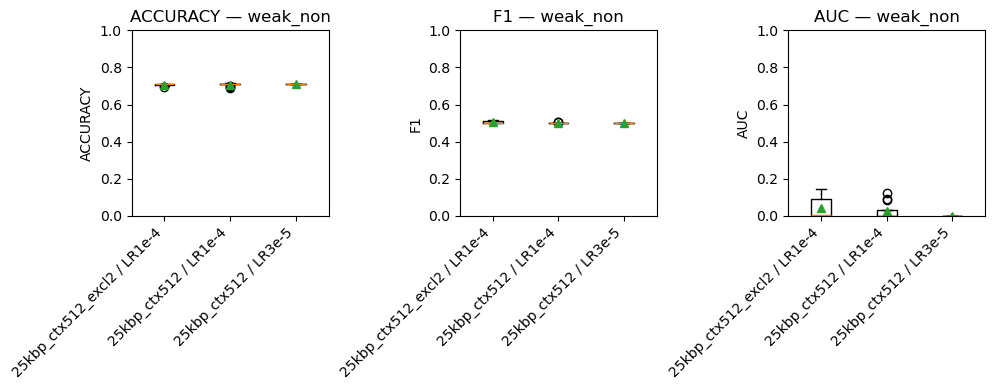

In [33]:
import matplotlib.pyplot as plt

def plot_task_boxes(task_name: str, use_violin=False, order_by="f1_mean", save=True, y_min=0.0, y_max=1.0):
    sub = df[df["task"] == task_name].copy()
    if sub.empty:
        print(f"[{task_name}] no rows.")
        return

    sub_sum = summary[summary["task"] == task_name].copy()
    if sub_sum.empty:
        print(f"[{task_name}] no summary rows.")
        return
    if order_by not in sub_sum.columns:
        order_by = "f1_mean" if "f1_mean" in sub_sum.columns else sub_sum.columns[-1]

    order = sub_sum.sort_values(order_by, ascending=False)["condition"].tolist()

    metrics = ["accuracy","f1","auc"]
    titles  = ["ACCURACY","F1","AUC"]

    fig, axes = plt.subplots(1, 3, figsize=(max(10, 0.7*len(order)), 4), squeeze=False)
    axes = axes[0]

    for ax, metric, title in zip(axes, metrics, titles):
        data = [sub.loc[sub["condition"]==c, metric].dropna().values for c in order]

        if use_violin:
            ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
            ax.set_xticks(range(1, len(order)+1))
            ax.set_xticklabels(order, rotation=45, ha="right")
        else:
            ax.boxplot(data, labels=order, showmeans=True)
            for label in ax.get_xticklabels():
                label.set_rotation(45); label.set_ha("right")

        ax.set_ylabel(title)
        ax.set_title(f"{title} — {task_name}")
        ax.set_ylim(y_min, y_max)   # <<< set y-axis to [0, 1]

    plt.tight_layout()
    if save:
        out = f"figs/{task_name}_{'violin' if use_violin else 'box'}.png".replace(" ","_")
        plt.savefig(out, dpi=200)
        print("Saved:", out)
    plt.show()

# Example:
for t in sorted(df["task"].dropna().unique()):
    plot_task_boxes(t, use_violin=False, order_by="f1_mean", y_min=0.0, y_max=1.0)


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1677572368.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=short_order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1677572368.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=short_order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1677572368.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=short_order, showmeans=True)
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934

Saved: figs/all_tasks_box_grid.png


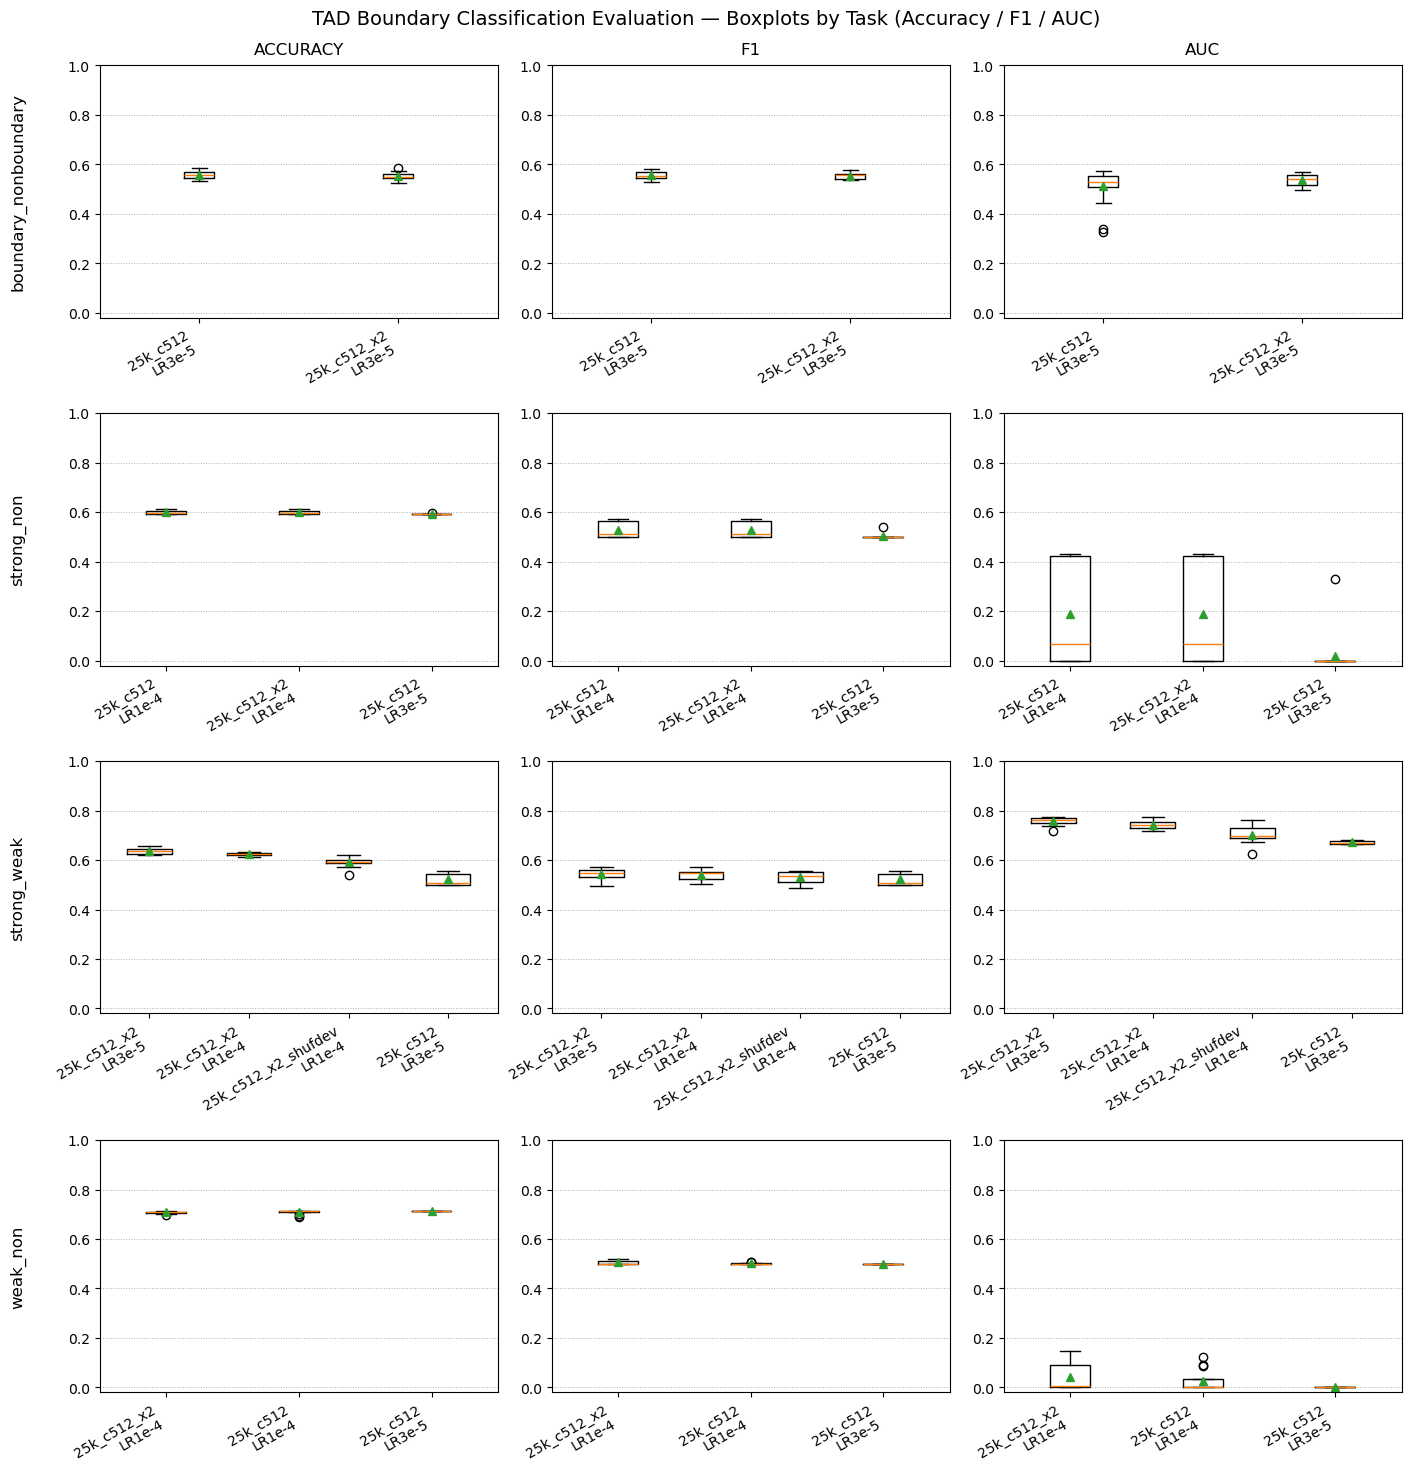

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import re

def _shorten_label(s: str):
    s = s.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    s = re.sub(r"\s*/\s*LR", "\nLR", s)
    return s

def plot_all_tasks_boxgrid(order_by="f1_mean",
                           y_min=0.0, y_max=1.0, tick_step=0.2,
                           bottom_pad=0.02,  # small pad below zero to avoid visual clipping
                           show=True, save=True, outfile="figs/all_tasks_box_grid.png"):

    tasks   = sorted(df["task"].dropna().unique())
    metrics = ["accuracy", "f1", "auc"]
    titles  = ["ACCURACY", "F1", "AUC"]

    nrows, ncols = len(tasks), len(metrics)
    max_conds = summary.groupby("task")["condition"].nunique().max()

    fig_w = max(14, 0.75 * max_conds * ncols)
    fig_h = max(3.6 * nrows, 3.6)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharey=True,
        constrained_layout=True
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, pad=8)

    yticks = np.arange(y_min, y_max + 1e-9, tick_step)

    for i, task in enumerate(tasks):
        sub_df  = df[df["task"] == task].copy()
        sub_sum = summary[summary["task"] == task].copy()
        if sub_df.empty or sub_sum.empty:
            continue

        if order_by not in sub_sum.columns:
            order_by = "f1_mean" if "f1_mean" in sub_sum.columns else sub_sum.columns[-1]

        order = sub_sum.sort_values(order_by, ascending=False)["condition"].tolist()
        short_order = [_shorten_label(c) for c in order]

        axes[i, 0].set_ylabel(task, fontsize=12, rotation=90, labelpad=30)

        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            data = [sub_df.loc[sub_df["condition"] == c, metric].dropna().values for c in order]

            bp = ax.boxplot(data, labels=short_order, showmeans=True)
            ax.set_xticklabels(short_order, rotation=30, ha="right")

            # ⬇️ pad bottom a bit so tiny values (~0.0) don't look "cut"
            ax.set_ylim(y_min - bottom_pad, y_max)
            ax.set_yticks(yticks)
            ax.tick_params(axis="y", labelleft=True)
            ax.grid(True, axis="y", linestyle=":", linewidth=0.7)

    fig.suptitle("TAD Boundary Classification Evaluation — Boxplots by Task (Accuracy / F1 / AUC)",
                 fontsize=14, y=1.02)

    if save:
        plt.savefig(outfile, dpi=200, bbox_inches="tight", pad_inches=0.5)
        print("Saved:", outfile)

    if show:
        plt.show()

# ✅ Call it
plot_all_tasks_boxgrid(order_by="f1_mean",
                       y_min=0.0, y_max=1.0, tick_step=0.2,
                       bottom_pad=0.02)


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1639235286.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1639235286.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1639235286.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/1639235286.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

Saved: figs/all_tasks_box_grid.png


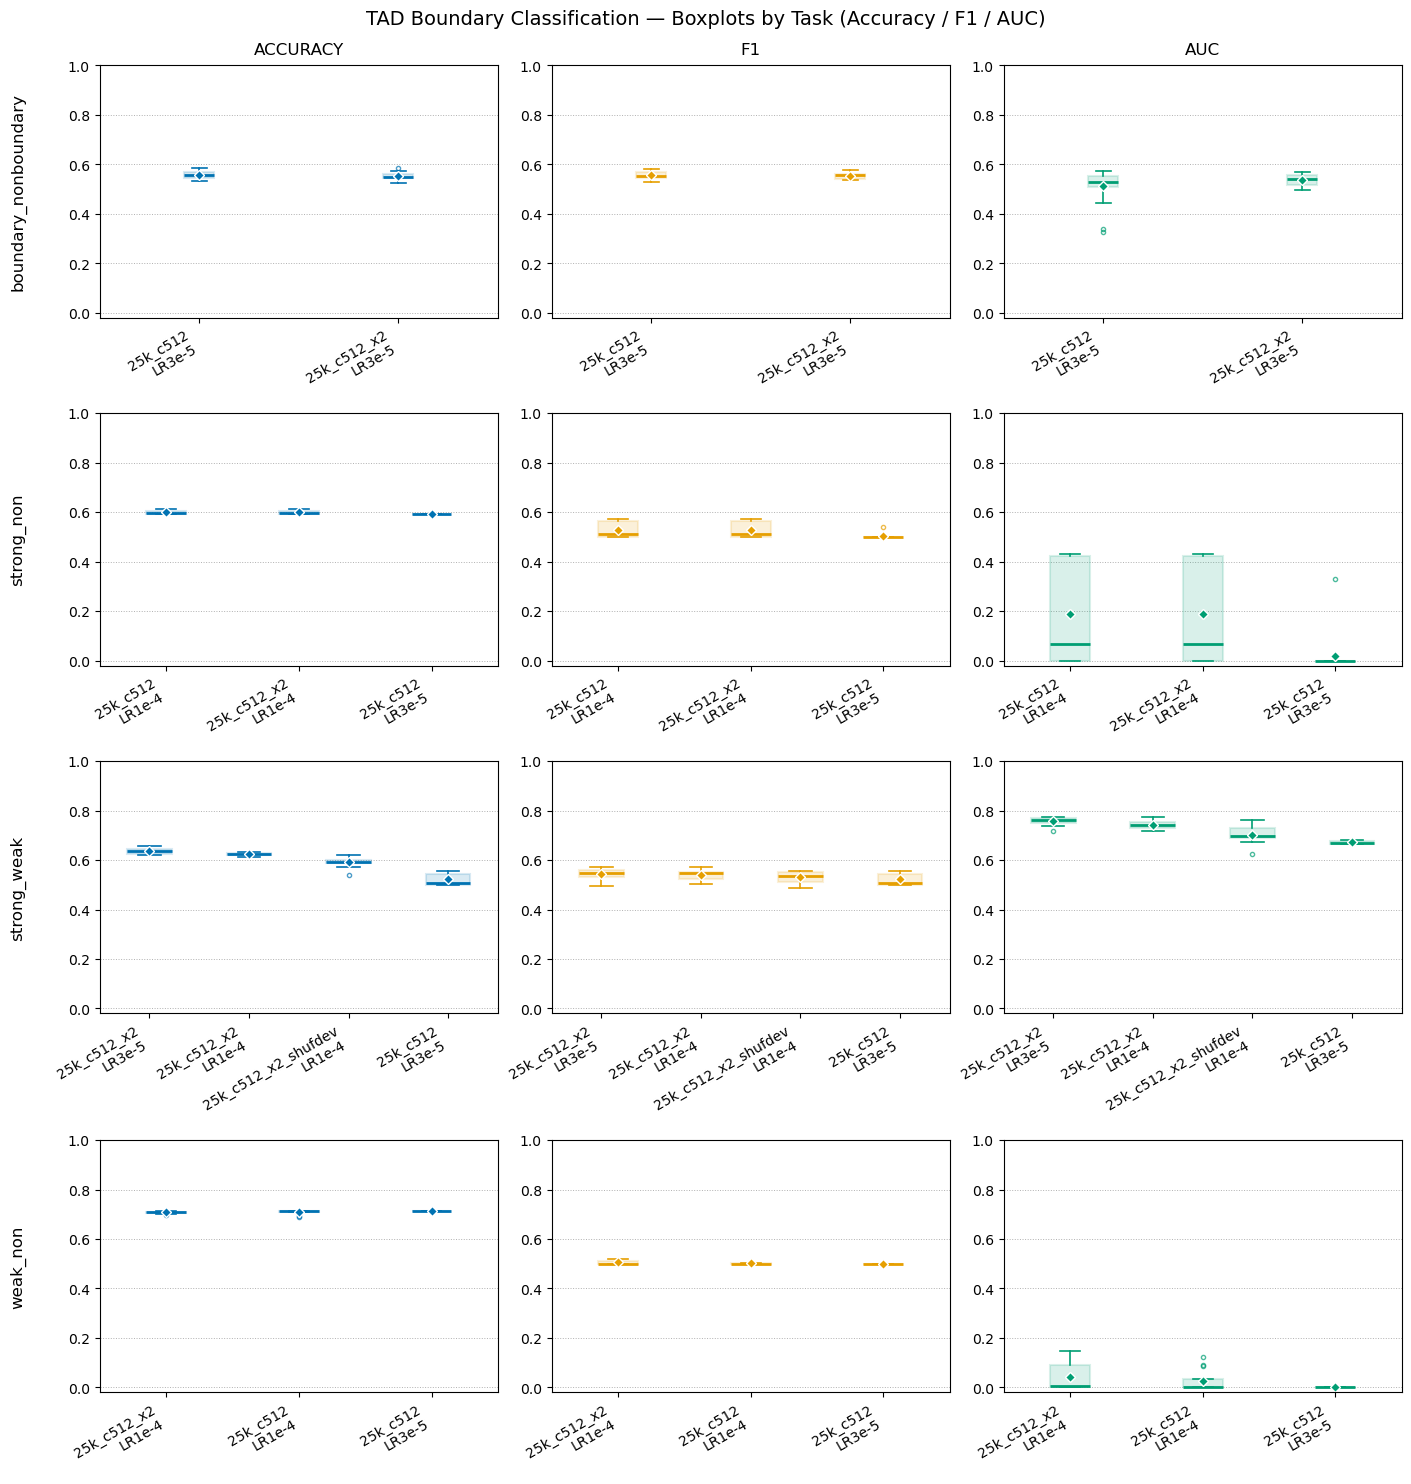

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

# metric-wise colors (friendly, colorblind-aware-ish)
# METRIC_COLORS = {
#     "accuracy": "#1f77b4",  # blue
#     "f1":       "#2ca02c",  # green
#     "auc":      "#d62728",  # red
# }
METRIC_COLORS = {
    "accuracy": "#0072B2",  # deep blue
    "f1":       "#E69F00",  # warm orange
    "auc":      "#009E73",  # teal green
}


def _shorten_label(s: str):
    s = s.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    s = re.sub(r"\s*/\s*LR", "\nLR", s)
    return s

def plot_all_tasks_boxgrid(order_by="f1_mean",
                           y_min=0.0, y_max=1.0, tick_step=0.2,
                           bottom_pad=0.02,
                           show=True, save=True, outfile="figs/all_tasks_box_grid.png"):

    tasks   = sorted(df["task"].dropna().unique())
    metrics = ["accuracy", "f1", "auc"]
    titles  = ["ACCURACY", "F1", "AUC"]

    nrows, ncols = len(tasks), len(metrics)
    max_conds = summary.groupby("task")["condition"].nunique().max()

    fig_w = max(14, 0.75 * max_conds * ncols)
    fig_h = max(3.6 * nrows, 3.6)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharey=True,
        constrained_layout=True
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    # Column titles
    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, pad=8)

    yticks = np.arange(y_min, y_max + 1e-9, tick_step)

    for i, task in enumerate(tasks):
        sub_df  = df[df["task"] == task].copy()
        sub_sum = summary[summary["task"] == task].copy()
        if sub_df.empty or sub_sum.empty:
            continue

        if order_by not in sub_sum.columns:
            order_by = "f1_mean" if "f1_mean" in sub_sum.columns else sub_sum.columns[-1]

        order = sub_sum.sort_values(order_by, ascending=False)["condition"].tolist()
        short_order = [_shorten_label(c) for c in order]

        # Row label
        axes[i, 0].set_ylabel(task, fontsize=12, rotation=90, labelpad=30)

        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            color = METRIC_COLORS[metric]
            data = [sub_df.loc[sub_df["condition"] == c, metric].dropna().values for c in order]

            # Colored boxplot
            bp = ax.boxplot(
                data,
                labels=short_order,
                showmeans=True,
                patch_artist=True,  # allow facecolor
                boxprops=dict(edgecolor=color, linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                medianprops=dict(color=color, linewidth=2.0),
                meanprops=dict(marker='D', markerfacecolor=color, markeredgecolor='white', markersize=5),
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor=color, markersize=3, alpha=0.7),
            )
            # light fill for boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.15)

            ax.set_xticklabels(short_order, rotation=30, ha="right")
            ax.set_ylim(y_min - bottom_pad, y_max)
            ax.set_yticks(np.arange(y_min, y_max + 1e-9, tick_step))
            ax.tick_params(axis="y", labelleft=True)
            ax.grid(True, axis="y", linestyle=":", linewidth=0.7)

    # Legend (metric color keys)
    legend_elems = [Line2D([0], [0], color=METRIC_COLORS[m], lw=3, label=titles[k])
                    for k, m in enumerate(metrics)]
    # fig.legend(handles=legend_elems, loc="upper right", frameon=False)

    fig.suptitle("TAD Boundary Classification — Boxplots by Task (Accuracy / F1 / AUC)", fontsize=14, y=1.02)

    if save:
        plt.savefig(outfile, dpi=200, bbox_inches="tight", pad_inches=0.5)
        print("Saved:", outfile)
    if show:
        plt.show()

# Run it
plot_all_tasks_boxgrid(order_by="f1_mean",
                       y_min=0.0, y_max=1.0, tick_step=0.2,
                       bottom_pad=0.02)


In [51]:
import pandas as pd, numpy as np

df = pd.read_csv("./TAD/TAD_boundary/classification/weak_non/25kbp_ctx512_excl2/LR1e-4/pred_results.csv", skiprows=1, header=None)
df.columns = ["true", "logit0", "logit1"]

# compute probability of class 1 and binary prediction
logits = df[["logit0", "logit1"]].to_numpy()
exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
df["prob1"] = probs[:, 1]
df["pred"] = (df["prob1"] >= 0.5).astype(int)

print(df.head())
print("Counts:\n", df["true"].value_counts())
print("Confusion matrix test:")
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df["true"], df["pred"]))


   true    logit0    logit1     prob1  pred
0   1.0  0.349463 -0.428602  0.314737     0
1   0.0 -0.087327  0.142409  0.557183     1
2   0.0  0.704091 -0.868715  0.171817     0
3   0.0  0.336050 -0.462012  0.310440     0
4   0.0  0.336050 -0.462012  0.310440     0
Counts:
 true
0.0    332
1.0    135
Name: count, dtype: int64
Confusion matrix test:
[[315  17]
 [125  10]]


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/4277113826.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


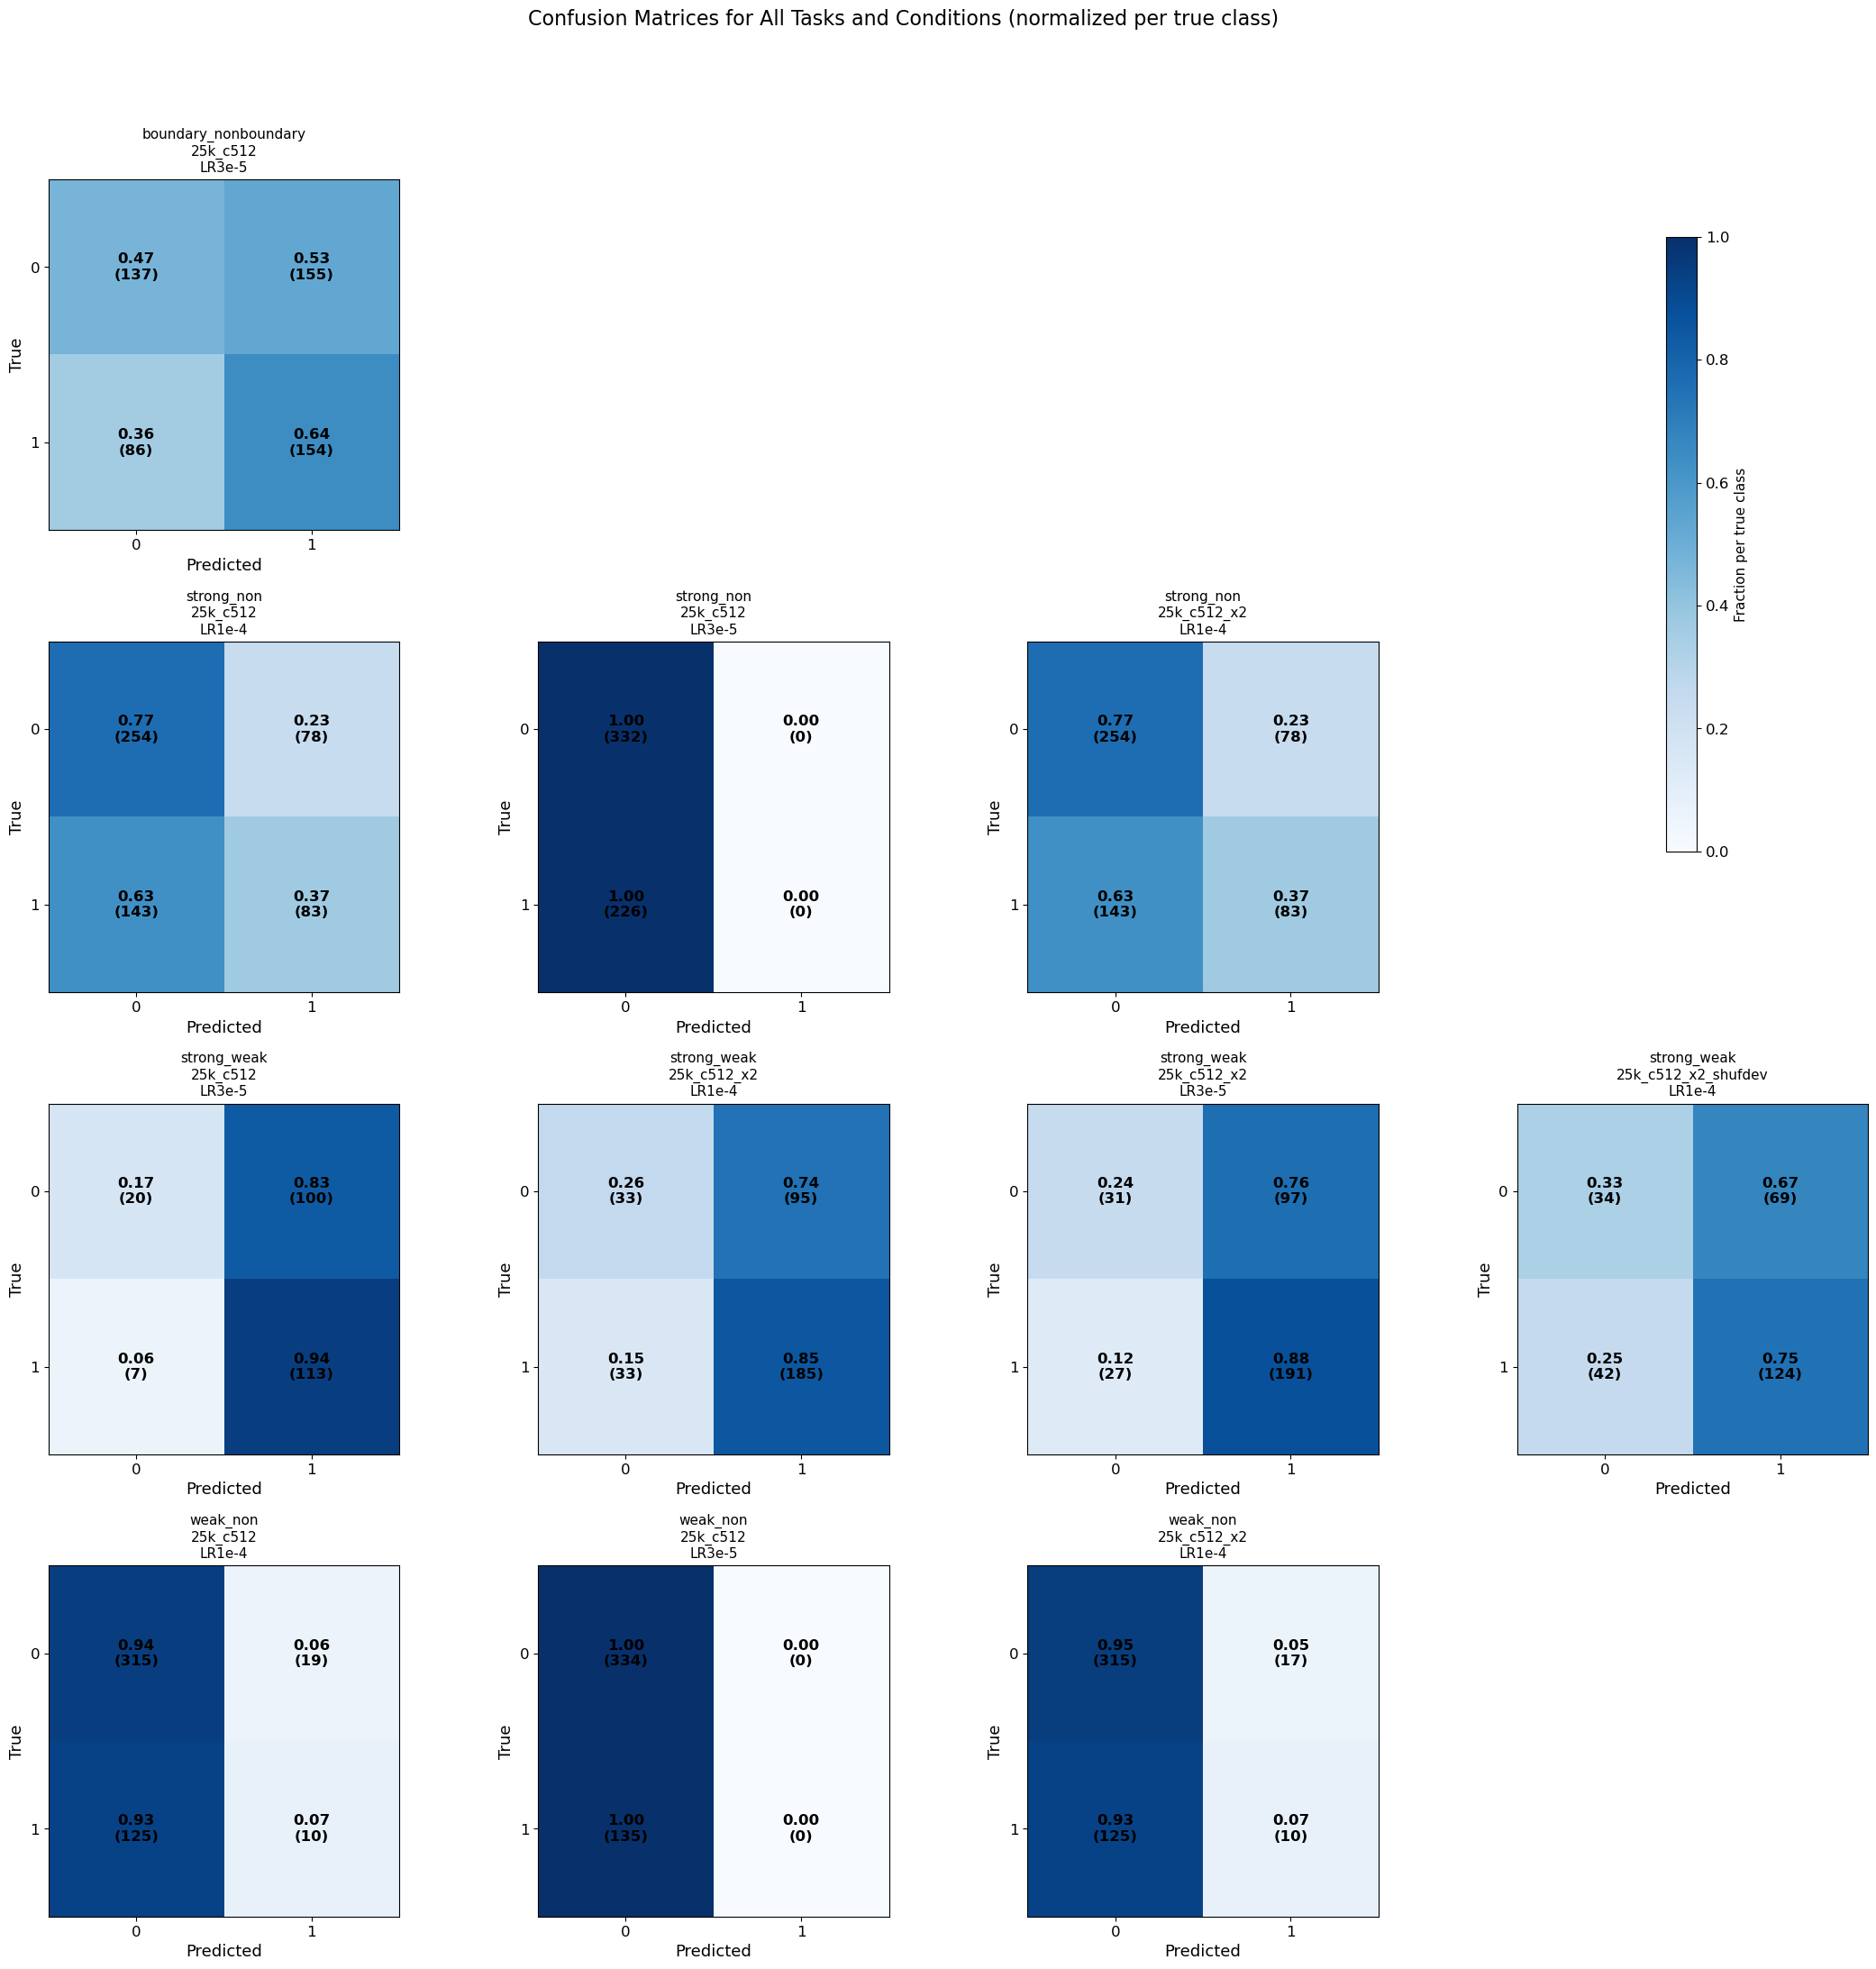

In [61]:
# === Confusion matrices for all tasks/conditions (header-safe, robust) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path
import re
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 20,          # base font
    "axes.titlesize": 20,     # per-panel title
    "axes.labelsize": 13,     # axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 20,   # suptitle
})

ROOT = Path("./TAD/TAD_boundary/classification")
RE_LR = re.compile(r"^LR([0-9eE\.\-]+)$")

def parse_lr_from_folder(lr_folder: str):
    m = RE_LR.match(lr_folder or "")
    return (lr_folder, float(m.group(1))) if m else (lr_folder, np.nan)

def shorten_condition(label: str) -> str:
    s = label.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    return re.sub(r"\s*/\s*LR", "\nLR", s)

def _needs_skip_first_line(path: Path) -> bool:
    """Return True if the first line looks like a header (contains letters)."""
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            first = fh.readline().strip()
        return bool(re.search(r"[A-Za-z]", first))
    except Exception:
        return False

def load_preds_csv(path: Path):
    """
    Returns y_true, y_pred, classes or (None,None,None) if invalid.
    - Skips header if the first line has letters (e.g., 'True_RPKM,Predicted_RPKM').
    - Supports 2 cols (true, prob) and 3 cols (true, logit0, logit1).
    """
    skip_first = _needs_skip_first_line(path)
    try:
        df = pd.read_csv(
            path,
            header=None,
            skiprows=1 if skip_first else 0,
            on_bad_lines="skip",
            comment="#",
            dtype=str  # read as strings first; we will coerce
        )
    except Exception:
        return None, None, None

    if df.empty:
        return None, None, None

    # Keep only first 3 columns if extra present
    if df.shape[1] > 3:
        df = df.iloc[:, :3]

    # 2-column case: [true, prob]
    if df.shape[1] == 2:
        df.columns = ["true", "pred_score"]
        df["true"] = pd.to_numeric(df["true"], errors="coerce")
        df["pred_score"] = pd.to_numeric(df["pred_score"], errors="coerce")
        df = df.dropna(subset=["true", "pred_score"])
        if df.empty: return None, None, None
        y_true = df["true"].astype(int).to_numpy()
        y_pred = (df["pred_score"] >= 0.5).astype(int).to_numpy()

    # 3-column case: [true, logit0, logit1]
    elif df.shape[1] == 3:
        df.columns = ["true", "logit0", "logit1"]
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.dropna(subset=["true", "logit0", "logit1"])
        if df.empty: return None, None, None
        logits = df[["logit0", "logit1"]].to_numpy()
        # stable softmax to get P(class=1)
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        prob1 = exp[:, 1] / exp.sum(axis=1)
        y_true = df["true"].astype(int).to_numpy()
        y_pred = (prob1 >= 0.5).astype(int)

    else:
        return None, None, None

    classes = np.unique(np.concatenate([y_true, y_pred]))
    return y_true, y_pred, classes

# ---- Collect all confusion matrices ----
records = []
for f in ROOT.rglob("pred_results.csv"):
    parts = f.parts
    try:
        idx = parts.index("classification")
    except ValueError:
        continue
    task   = parts[idx+1] if len(parts)>idx+1 else None
    config = parts[idx+2] if len(parts)>idx+2 else None
    lr_dir = parts[idx+3] if len(parts)>idx+3 else None
    lr_label, _ = parse_lr_from_folder(lr_dir)
    condition = f"{config} / {lr_label}"

    y_true, y_pred, classes = load_preds_csv(f)
    if y_true is None or y_true.size == 0:
        print(f"⚠️ Skipped {f}: could not parse predictions (check header/columns)")
        continue

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    records.append({
        "task": task,
        "condition": condition,
        "condition_short": shorten_condition(condition),
        "classes": classes,
        "cm": cm,
        "cm_norm": cm_norm
    })

if not records:
    raise ValueError("No valid prediction files found after header skipping. Inspect one CSV with `head` to confirm.")

# ---- Organize by task ----
tasks = sorted({r["task"] for r in records})
task_to_records = {t: sorted([r for r in records if r["task"] == t],
                             key=lambda r: r["condition"]) for t in tasks}

# ---- Plot grid (normalized; shows fraction and raw count) ----
fig_rows = len(tasks)
fig_cols = max(len(v) for v in task_to_records.values())
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(5.5*fig_cols, 5.5*fig_rows))

if fig_rows == 1 and fig_cols == 1: axes = np.array([[axes]])
elif fig_rows == 1: axes = np.array([axes])
elif fig_cols == 1: axes = axes.reshape(-1, 1)

im = None
for i, task in enumerate(tasks):
    recs = task_to_records[task]
    for j, rec in enumerate(recs):
        ax = axes[i, j]
        im = ax.imshow(rec["cm_norm"], cmap="Blues", vmin=0.0, vmax=1.0)
        # annotate with fraction and raw count
        for (x, y), frac in np.ndenumerate(rec["cm_norm"]):
            count = rec["cm"][x, y]
            ax.text(y, x, f"{frac:.2f}\n({count})", ha="center", va="center",
                    fontsize=12, color="black", weight="bold")
        ax.set_title(f"{task}\n{rec['condition_short']}", fontsize=11, pad=6)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(rec["classes"]))); ax.set_yticks(range(len(rec["classes"])))
        labels = [str(c) for c in rec["classes"]]
        ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    for j in range(len(recs), fig_cols):
        axes[i, j].axis("off")

# Remove/replace your existing colorbar block with:
cbar = fig.colorbar(
    im, ax=axes,
    orientation="vertical",
    location="right",   # requires matplotlib ≥ 3.6
    fraction=0.02,
    pad=0.02,
    anchor=(1, 1)       # align to upper-right
)
cbar.set_label("Fraction per true class", fontsize=11)
fig.suptitle("Confusion Matrices for All Tasks and Conditions (normalized per true class)", fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])

Path("figs").mkdir(parents=True, exist_ok=True)
plt.savefig("figs/confusion_matrices_all_normalized.png", dpi=200, bbox_inches="tight")
plt.show()


In [66]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

ROOT = Path("./TAD/TAD_boundary_updated/classification")

RE_KBP  = re.compile(r"(\d+)kbp")
RE_CTX  = re.compile(r"ctx(\d+)")
RE_EXCL = re.compile(r"excl(\d+)")
RE_LR   = re.compile(r"^LR([0-9eE\.\-]+)$")

def parse_hparams(config_str: str):
    kbp  = RE_KBP.search(config_str or "")
    ctx  = RE_CTX.search(config_str or "")
    excl = RE_EXCL.search(config_str or "")
    flags = []
    for token in (config_str or "").split("_"):
        if not token: continue
        if RE_KBP.search(token) or RE_CTX.search(token) or RE_EXCL.search(token):
            continue
        flags.append(token)
    return {
        "kbp":  kbp.group(1) if kbp else None,
        "ctx":  ctx.group(1) if ctx else None,
        "excl": excl.group(1) if excl else None,
        "flags": ",".join(flags) if flags else ""
    }

def parse_lr_from_folder(lr_folder: str):
    m = RE_LR.match(lr_folder or "")
    if m:
        try:    return lr_folder, float(m.group(1))
        except: return lr_folder, np.nan
    return lr_folder, np.nan

def safe_float(x):
    try:    return float(x)
    except: return np.nan

rows = []
for f in ROOT.rglob("eval_results.txt"):
    parts = f.parts
    idx = parts.index("classification")
    task   = parts[idx+1] if len(parts)>idx+1 else None
    config = parts[idx+2] if len(parts)>idx+2 else None
    lr_dir = parts[idx+3] if len(parts)>idx+3 else None
    hp = parse_hparams(config)
    lr_label, lr_float = parse_lr_from_folder(lr_dir)

    with f.open() as fh:
        run_id = 0
        for line in fh:
            toks = line.strip().split()
            if len(toks) < 4: 
                continue
            acc, f1, auc = map(safe_float, toks[-3:])
            name_token = " ".join(toks[:-3])
            rows.append({
                "task": task,
                "config": config,
                "lr_folder": lr_label,
                "lr_float": lr_float,
                "kbp": hp["kbp"], "ctx": hp["ctx"], "excl": hp["excl"], "flags": hp["flags"],
                "condition": f"{config} / {lr_label}",
                "name_token": name_token,
                "run_id": run_id,
                "accuracy": acc, "f1": f1, "auc": auc,
                "file": str(f)
            })
            run_id += 1

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(137, 15)


,task,config,lr_folder,lr_float,kbp,ctx,excl,flags,condition,name_token,run_id,accuracy,f1,auc,file
0,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,0,0.773,0.500,0.000,TAD/TAD_boundary_updated/classification/strong...
1,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,1,0.775,0.504,0.017,TAD/TAD_boundary_updated/classification/strong...
2,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,2,0.787,0.591,0.331,TAD/TAD_boundary_updated/classification/strong...
3,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,3,0.785,0.548,0.196,TAD/TAD_boundary_updated/classification/strong...
4,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,4,0.791,0.606,0.368,TAD/TAD_boundary_updated/classification/strong...


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/7007973.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/7007973.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/7007973.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_74934/7007973.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

Saved: figs/all_tasks_box_grid_updated.png


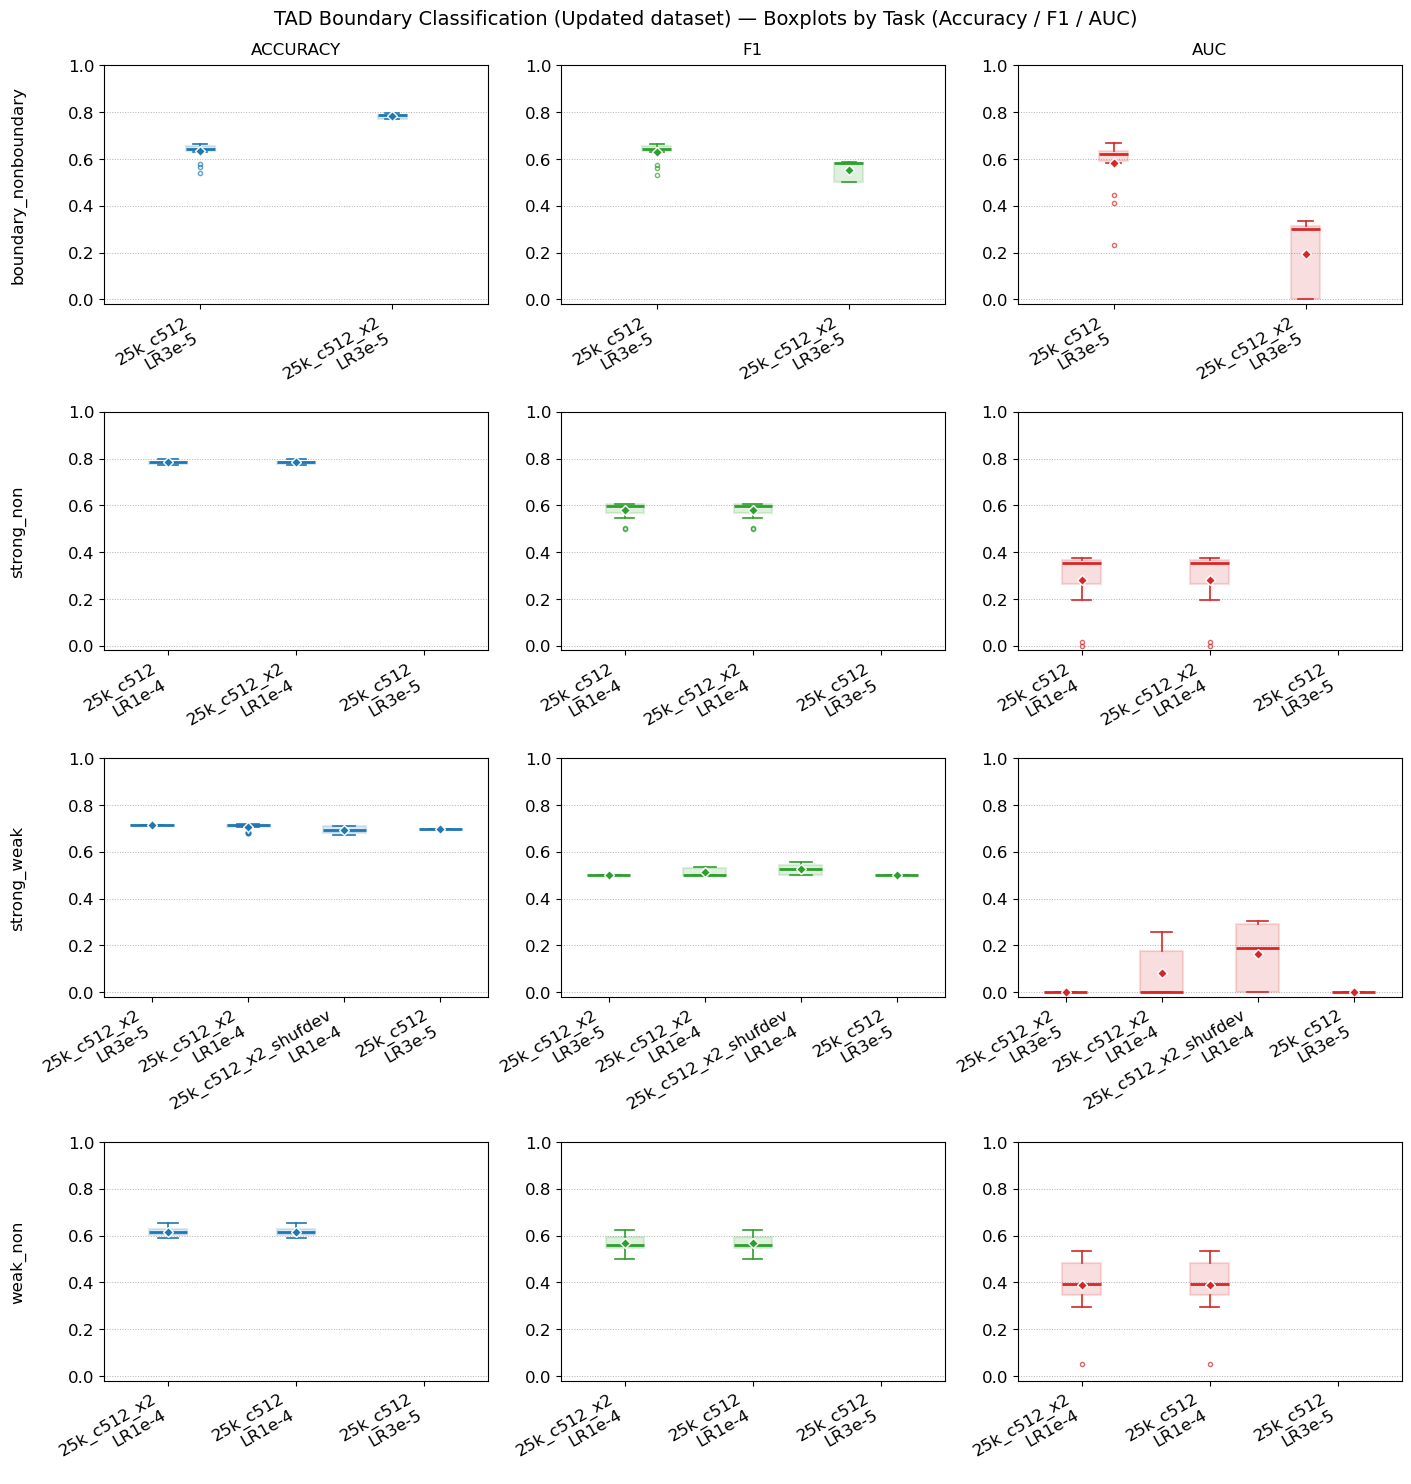

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

# metric-wise colors (friendly, colorblind-aware-ish)
METRIC_COLORS = {
    "accuracy": "#1f77b4",  # blue
    "f1":       "#2ca02c",  # green
    "auc":      "#d62728",  # red
}
# METRIC_COLORS = {
#     "accuracy": "#0072B2",  # deep blue
#     "f1":       "#E69F00",  # warm orange
#     "auc":      "#009E73",  # teal green
# }
# METRIC_COLORS = {
#     "accuracy": "#7D5B3F",  # Brown
#     "f1":       "#B09E80",  # Tan
#     "auc":      "#938563",  # Olive Green
# }


def _shorten_label(s: str):
    s = s.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    s = re.sub(r"\s*/\s*LR", "\nLR", s)
    return s

def plot_all_tasks_boxgrid(order_by="f1_mean",
                           y_min=0.0, y_max=1.0, tick_step=0.2,
                           bottom_pad=0.02,
                           show=True, save=True, outfile="figs/all_tasks_box_grid_updated.png"):

    tasks   = sorted(df["task"].dropna().unique())
    metrics = ["accuracy", "f1", "auc"]
    titles  = ["ACCURACY", "F1", "AUC"]

    nrows, ncols = len(tasks), len(metrics)
    max_conds = summary.groupby("task")["condition"].nunique().max()

    fig_w = max(14, 0.75 * max_conds * ncols)
    fig_h = max(3.6 * nrows, 3.6)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharey=True,
        constrained_layout=True
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    # Column titles
    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, pad=8)

    yticks = np.arange(y_min, y_max + 1e-9, tick_step)

    for i, task in enumerate(tasks):
        sub_df  = df[df["task"] == task].copy()
        sub_sum = summary[summary["task"] == task].copy()
        if sub_df.empty or sub_sum.empty:
            continue

        if order_by not in sub_sum.columns:
            order_by = "f1_mean" if "f1_mean" in sub_sum.columns else sub_sum.columns[-1]

        order = sub_sum.sort_values(order_by, ascending=False)["condition"].tolist()
        short_order = [_shorten_label(c) for c in order]

        # Row label
        axes[i, 0].set_ylabel(task, fontsize=12, rotation=90, labelpad=30)

        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            color = METRIC_COLORS[metric]
            data = [sub_df.loc[sub_df["condition"] == c, metric].dropna().values for c in order]

            # Colored boxplot
            bp = ax.boxplot(
                data,
                labels=short_order,
                showmeans=True,
                patch_artist=True,  # allow facecolor
                boxprops=dict(edgecolor=color, linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                medianprops=dict(color=color, linewidth=2.0),
                meanprops=dict(marker='D', markerfacecolor=color, markeredgecolor='white', markersize=5),
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor=color, markersize=3, alpha=0.7),
            )
            # light fill for boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.15)

            ax.set_xticklabels(short_order, rotation=30, ha="right")
            ax.set_ylim(y_min - bottom_pad, y_max)
            ax.set_yticks(np.arange(y_min, y_max + 1e-9, tick_step))
            ax.tick_params(axis="y", labelleft=True)
            ax.grid(True, axis="y", linestyle=":", linewidth=0.7)

    # Legend (metric color keys)
    legend_elems = [Line2D([0], [0], color=METRIC_COLORS[m], lw=3, label=titles[k])
                    for k, m in enumerate(metrics)]
    # fig.legend(handles=legend_elems, loc="upper right", frameon=False)

    fig.suptitle("TAD Boundary Classification (Updated dataset) — Boxplots by Task (Accuracy / F1 / AUC)", fontsize=14, y=1.02)

    if save:
        plt.savefig(outfile, dpi=200, bbox_inches="tight", pad_inches=0.5)
        print("Saved:", outfile)
    if show:
        plt.show()

# Run it
plot_all_tasks_boxgrid(order_by="f1_mean",
                       y_min=0.0, y_max=1.0, tick_step=0.2,
                       bottom_pad=0.02)

In [6]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

ROOT = Path("./TAD/TAD_boundary_ft5cells/classification")

RE_KBP  = re.compile(r"(\d+)kbp")
RE_CTX  = re.compile(r"ctx(\d+)")
RE_EXCL = re.compile(r"excl(\d+)")
RE_LR   = re.compile(r"^LR([0-9eE\.\-]+)$")

def parse_hparams(config_str: str):
    kbp  = RE_KBP.search(config_str or "")
    ctx  = RE_CTX.search(config_str or "")
    excl = RE_EXCL.search(config_str or "")
    flags = []
    for token in (config_str or "").split("_"):
        if not token: continue
        if RE_KBP.search(token) or RE_CTX.search(token) or RE_EXCL.search(token):
            continue
        flags.append(token)
    return {
        "kbp":  kbp.group(1) if kbp else None,
        "ctx":  ctx.group(1) if ctx else None,
        "excl": excl.group(1) if excl else None,
        "flags": ",".join(flags) if flags else ""
    }

def parse_lr_from_folder(lr_folder: str):
    m = RE_LR.match(lr_folder or "")
    if m:
        try:    return lr_folder, float(m.group(1))
        except: return lr_folder, np.nan
    return lr_folder, np.nan

def safe_float(x):
    try:    return float(x)
    except: return np.nan

rows = []
for f in ROOT.rglob("eval_results.txt"):
    parts = f.parts
    idx = parts.index("classification")
    task   = parts[idx+1] if len(parts)>idx+1 else None
    config = parts[idx+2] if len(parts)>idx+2 else None
    lr_dir = parts[idx+3] if len(parts)>idx+3 else None
    hp = parse_hparams(config)
    lr_label, lr_float = parse_lr_from_folder(lr_dir)

    with f.open() as fh:
        run_id = 0
        for line in fh:
            toks = line.strip().split()
            if len(toks) < 4: 
                continue
            acc, f1, auc = map(safe_float, toks[-3:])
            name_token = " ".join(toks[:-3])
            rows.append({
                "task": task,
                "config": config,
                "lr_folder": lr_label,
                "lr_float": lr_float,
                "kbp": hp["kbp"], "ctx": hp["ctx"], "excl": hp["excl"], "flags": hp["flags"],
                "condition": f"{config} / {lr_label}",
                "name_token": name_token,
                "run_id": run_id,
                "accuracy": acc, "f1": f1, "auc": auc,
                "file": str(f)
            })
            run_id += 1

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(402, 15)


,task,config,lr_folder,lr_float,kbp,ctx,excl,flags,condition,name_token,run_id,accuracy,f1,auc,file
0,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,0,0.685,0.500,0.000,TAD/TAD_boundary_ft5cells/classification/stron...
1,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,1,0.685,0.500,0.000,TAD/TAD_boundary_ft5cells/classification/stron...
2,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,2,0.720,0.589,0.346,TAD/TAD_boundary_ft5cells/classification/stron...
3,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,3,0.718,0.579,0.316,TAD/TAD_boundary_ft5cells/classification/stron...
4,strong_non,25kbp_ctx512_excl2,LR1e-4,0.0001,25,512,2,,25kbp_ctx512_excl2 / LR1e-4,25kbp_ctx512_excl2,4,0.727,0.583,0.312,TAD/TAD_boundary_ft5cells/classification/stron...


In [7]:
metrics = ["accuracy","f1","auc"]
summary = (
    df.groupby(["task","condition"])[metrics]
      .agg(["mean","std","count"])
      .reset_index()
)
# Flatten multiindex columns like ('f1','mean') -> 'f1_mean'
summary.columns = ["_".join(c).strip("_") for c in summary.columns.to_flat_index()]

# sanity check
print(summary.columns.tolist())
summary.head()

['task', 'condition', 'accuracy_mean', 'accuracy_std', 'accuracy_count', 'f1_mean', 'f1_std', 'f1_count', 'auc_mean', 'auc_std', 'auc_count']


,task,condition,accuracy_mean,accuracy_std,accuracy_count,f1_mean,f1_std,f1_count,auc_mean,auc_std,auc_count
0,boundary_nonboundary,25kbp_ctx512_excl2 / LR1e-4,0.655243,0.014946,111,0.646171,0.017261,111,0.700135,0.021323,111
1,boundary_nonboundary,25kbp_ctx512_excl2 / LR3e-5,0.660189,0.017088,111,0.648306,0.022299,111,0.711018,0.015899,111
2,strong_non,25kbp_ctx512_excl2 / LR1e-4,0.725831,0.012106,59,0.613915,0.026964,59,0.410119,0.089835,59
3,strong_non,25kbp_ctx512_excl2 / LR3e-5,0.728237,0.014039,59,0.614322,0.037357,59,0.402000,0.125822,59
4,strong_weak,25kbp_ctx512_excl2 / LR3e-5,0.632935,0.007050,62,0.516823,0.010304,62,0.140419,0.090339,62


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/772634125.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/772634125.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/772634125.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/772634125.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

Saved: figs/all_tasks_box_grid_updated.png


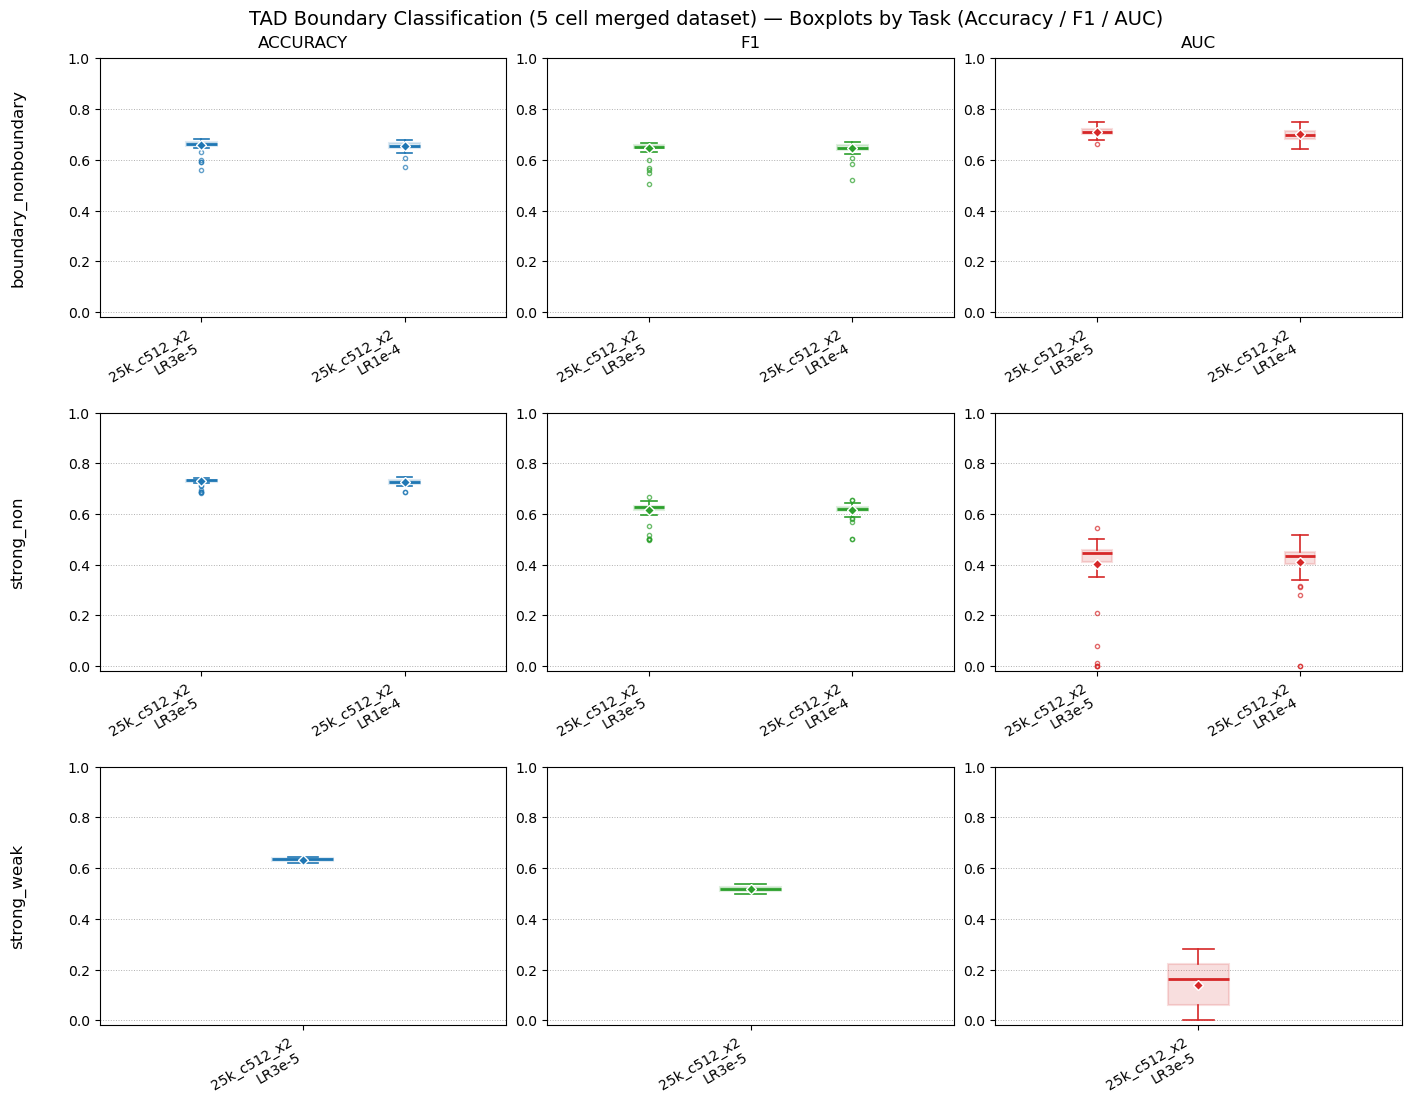

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

# metric-wise colors (friendly, colorblind-aware-ish)
METRIC_COLORS = {
    "accuracy": "#1f77b4",  # blue
    "f1":       "#2ca02c",  # green
    "auc":      "#d62728",  # red
}
# METRIC_COLORS = {
#     "accuracy": "#0072B2",  # deep blue
#     "f1":       "#E69F00",  # warm orange
#     "auc":      "#009E73",  # teal green
# }
# METRIC_COLORS = {
#     "accuracy": "#7D5B3F",  # Brown
#     "f1":       "#B09E80",  # Tan
#     "auc":      "#938563",  # Olive Green
# }


def _shorten_label(s: str):
    s = s.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    s = re.sub(r"\s*/\s*LR", "\nLR", s)
    return s

def plot_all_tasks_boxgrid(order_by="f1_mean",
                           y_min=0.0, y_max=1.0, tick_step=0.2,
                           bottom_pad=0.02,
                           show=True, save=True, outfile="figs/all_tasks_box_grid_updated.png"):

    tasks   = sorted(df["task"].dropna().unique())
    metrics = ["accuracy", "f1", "auc"]
    titles  = ["ACCURACY", "F1", "AUC"]

    nrows, ncols = len(tasks), len(metrics)
    max_conds = summary.groupby("task")["condition"].nunique().max()

    fig_w = max(14, 0.75 * max_conds * ncols)
    fig_h = max(3.6 * nrows, 3.6)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharey=True,
        constrained_layout=True
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    # Column titles
    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, pad=8)

    yticks = np.arange(y_min, y_max + 1e-9, tick_step)

    for i, task in enumerate(tasks):
        sub_df  = df[df["task"] == task].copy()
        sub_sum = summary[summary["task"] == task].copy()
        if sub_df.empty or sub_sum.empty:
            continue

        if order_by not in sub_sum.columns:
            order_by = "f1_mean" if "f1_mean" in sub_sum.columns else sub_sum.columns[-1]

        order = sub_sum.sort_values(order_by, ascending=False)["condition"].tolist()
        short_order = [_shorten_label(c) for c in order]

        # Row label
        axes[i, 0].set_ylabel(task, fontsize=12, rotation=90, labelpad=30)

        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            color = METRIC_COLORS[metric]
            data = [sub_df.loc[sub_df["condition"] == c, metric].dropna().values for c in order]

            # Colored boxplot
            bp = ax.boxplot(
                data,
                labels=short_order,
                showmeans=True,
                patch_artist=True,  # allow facecolor
                boxprops=dict(edgecolor=color, linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                medianprops=dict(color=color, linewidth=2.0),
                meanprops=dict(marker='D', markerfacecolor=color, markeredgecolor='white', markersize=5),
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor=color, markersize=3, alpha=0.7),
            )
            # light fill for boxes
            for patch in bp['boxes']:
                patch.set_facecolor(color)
                patch.set_alpha(0.15)

            ax.set_xticklabels(short_order, rotation=30, ha="right")
            ax.set_ylim(y_min - bottom_pad, y_max)
            ax.set_yticks(np.arange(y_min, y_max + 1e-9, tick_step))
            ax.tick_params(axis="y", labelleft=True)
            ax.grid(True, axis="y", linestyle=":", linewidth=0.7)

    # Legend (metric color keys)
    legend_elems = [Line2D([0], [0], color=METRIC_COLORS[m], lw=3, label=titles[k])
                    for k, m in enumerate(metrics)]
    # fig.legend(handles=legend_elems, loc="upper right", frameon=False)

    fig.suptitle("TAD Boundary Classification (5 cell merged dataset) — Boxplots by Task (Accuracy / F1 / AUC)", fontsize=14, y=1.02)

    if save:
        plt.savefig(outfile, dpi=200, bbox_inches="tight", pad_inches=0.5)
        print("Saved:", outfile)
    if show:
        plt.show()

# Run it
plot_all_tasks_boxgrid(order_by="f1_mean",
                       y_min=0.0, y_max=1.0, tick_step=0.2,
                       bottom_pad=0.02)

In [13]:
#!/usr/bin/env python3
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- helpers ----------
RE_KBP  = re.compile(r"(\d+)kbp")
RE_CTX  = re.compile(r"ctx(\d+)")
RE_EXCL = re.compile(r"excl(\d+)")
RE_LR   = re.compile(r"^LR([0-9eE\.\-]+)$")

def _normalize_task(name: str) -> str:
    if not name: return name
    s = name.lower()
    s = s.replace("-", "_").replace("__", "_")
    s = s.replace("vs_", "_").replace("_vs", "_").replace("_v_", "_")
    # common aliases
    s = s.replace("boundary_non", "boundary_nonboundary")
    s = s.replace("nonboundary_nonboundary", "nonboundary")  # safeguard
    s = s.replace("weak_nonboundary", "weak_non")
    s = s.replace("strong_nonboundary", "strong_non")
    s = s.replace("strong_weak", "strong_weak")
    return s

def parse_hparams(config_str: str):
    kbp  = RE_KBP.search(config_str or "")
    ctx  = RE_CTX.search(config_str or "")
    excl = RE_EXCL.search(config_str or "")
    flags = []
    for token in (config_str or "").split("_"):
        if not token: continue
        if RE_KBP.search(token) or RE_CTX.search(token) or RE_EXCL.search(token):
            continue
        flags.append(token)
    return {
        "kbp":  kbp.group(1) if kbp else None,
        "ctx":  ctx.group(1) if ctx else None,
        "excl": excl.group(1) if excl else None,
        "flags": ",".join(flags) if flags else ""
    }

def parse_lr_from_folder(lr_folder: str):
    m = RE_LR.match(lr_folder or "")
    if m:
        try:    return lr_folder, float(m.group(1))
        except: return lr_folder, np.nan
    return lr_folder, np.nan

def safe_float(x):
    try:    return float(x)
    except: return np.nan

def _shorten_label(s: str):
    s = (s or "")
    s = s.replace("25kbp_", "25k_").replace("ctx", "c").replace("_excl", "_x")
    s = re.sub(r"\s*/\s*LR", "\nLR", s)
    return s

# ---------- one-shot function ----------
def make_ft_report(root_dir: str, outfile="figs/all_tasks_box_grid.png",
                   order_by="f1_mean", y_min=0.0, y_max=1.0, tick_step=0.2,
                   bottom_pad=0.02, show=True, save=True):
    ROOT = Path(root_dir)
    rows = []
    found_files = list(ROOT.rglob("eval_results.txt"))
    if not found_files:
        print(f"[WARN] No eval_results.txt under: {ROOT.resolve()}")
        return None, None

    for f in found_files:
        parts = f.parts
        try:
            idx = parts.index("classification")
        except ValueError:
            # skip weird paths
            continue
        # be tolerant to extra nesting
        task = parts[idx+1] if len(parts) > idx+1 else None
        config = parts[idx+2] if len(parts) > idx+2 else None
        lr_dir = parts[idx+3] if len(parts) > idx+3 else None

        task_norm = _normalize_task(task)
        hp = parse_hparams(config)
        lr_label, lr_float = parse_lr_from_folder(lr_dir)

        with f.open() as fh:
            run_id = 0
            for line in fh:
                toks = line.strip().split()
                if len(toks) < 4: 
                    continue
                acc, f1, auc = map(safe_float, toks[-3:])
                name_token = " ".join(toks[:-3])
                rows.append({
                    "task": task_norm,
                    "raw_task": task,
                    "config": config,
                    "lr_folder": lr_label,
                    "lr_float": lr_float,
                    "kbp": hp["kbp"], "ctx": hp["ctx"], "excl": hp["excl"], "flags": hp["flags"],
                    "condition": f"{config} / {lr_label}",
                    "name_token": name_token,
                    "run_id": run_id,
                    "accuracy": acc, "f1": f1, "auc": auc,
                    "file": str(f)
                })
                run_id += 1

    df = pd.DataFrame(rows)
    if df.empty:
        print("[WARN] Collected 0 rows. Check file contents/format.")
        return None, None

    # Diagnostics
    print(f"[INFO] files scanned: {len(found_files)}")
    print("[INFO] tasks discovered (normalized → raw set):")
    for t, g in df.groupby("task"):
        raws = sorted(set(g["raw_task"].dropna().unique().tolist()))
        print(f"  - {t}: {raws}  (n={len(g)})")

    # Summary
    metrics = ["accuracy","f1","auc"]
    summary = (
        df.groupby(["task","condition"])[metrics]
          .agg(["mean","std","count"])
          .reset_index()
    )
    summary.columns = ["_".join(c).strip("_") for c in summary.columns.to_flat_index()]

    # Plot
    tasks = sorted(df["task"].dropna().unique())
    titles = ["ACCURACY","F1","AUC"]
    nrows, ncols = len(tasks), len(metrics)
    max_conds = summary.groupby("task")["condition"].nunique().max()
    fig_w = max(14, 0.75 * max_conds * ncols)
    fig_h = max(3.6 * nrows, 3.6)

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharey=False, constrained_layout=True)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    METRIC_COLORS = {"accuracy":"#1f77b4","f1":"#2ca02c","auc":"#d62728"}
    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, pad=8)

    yticks = np.arange(y_min, y_max + 1e-9, tick_step)

    for i, task in enumerate(tasks):
        sub_df  = df[df["task"] == task].copy()
        sub_sum = summary[summary["task"] == task].copy()
        if sub_df.empty or sub_sum.empty:
            continue

        key = order_by if order_by in sub_sum.columns else "f1_mean"
        order = sub_sum.sort_values(key, ascending=False)["condition"].tolist()
        short_order = [_shorten_label(c) for c in order]

        axes[i, 0].set_ylabel(task, fontsize=12, rotation=90, labelpad=30)

        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            color = METRIC_COLORS[metric]
            data = [sub_df.loc[sub_df["condition"] == c, metric].dropna().values for c in order]
            bp = ax.boxplot(
                data,
                labels=short_order,
                showmeans=True,
                patch_artist=True,
                boxprops=dict(edgecolor=color, linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                medianprops=dict(color=color, linewidth=2.0),
                meanprops=dict(marker='D', markerfacecolor=color, markeredgecolor='white', markersize=5),
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor=color, markersize=3, alpha=0.7),
            )
            for patch in bp['boxes']:
                patch.set_facecolor(color); patch.set_alpha(0.15)

            ax.set_xticklabels(short_order, rotation=30, ha="right")
            ax.set_ylim(y_min - bottom_pad, y_max)
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{t:.1f}" for t in yticks])
            ax.grid(True, axis="y", linestyle=":", linewidth=0.7)

    legend_elems = [Line2D([0], [0], color=METRIC_COLORS[m], lw=3, label=titles[k])
                    for k, m in enumerate(["accuracy","f1","auc"])]
    fig.suptitle("TAD Boundary Classification — Boxplots by Task (Accuracy / F1 / AUC)", fontsize=14, y=1.02)

    if save:
        outfile = str(outfile)
        Path(outfile).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(outfile, dpi=200, bbox_inches="tight", pad_inches=0.5)
        print("Saved:", outfile)
    if show:
        plt.show()

    return df, summary

# ---- Example one-liner call ----
# df, summary = make_ft_report("./TAD/TAD_boundary_ft5cells/classification",
#                              outfile="figs/ft5cells_boxgrid.png")


[INFO] files scanned: 8
[INFO] tasks discovered (normalized → raw set):
  - boundary_nonboundaryboundary: ['boundary_nonboundary']  (n=222)
  - strong_non: ['strong_non']  (n=118)
  - strong_weak: ['strong_weak']  (n=124)
  - weak_non: ['weak_non']  (n=152)


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/2012660229.py:171: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/2012660229.py:171: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/2012660229.py:171: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_1041/2012660229.py:171: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

Saved: figs/ft5cells_boxgrid.png


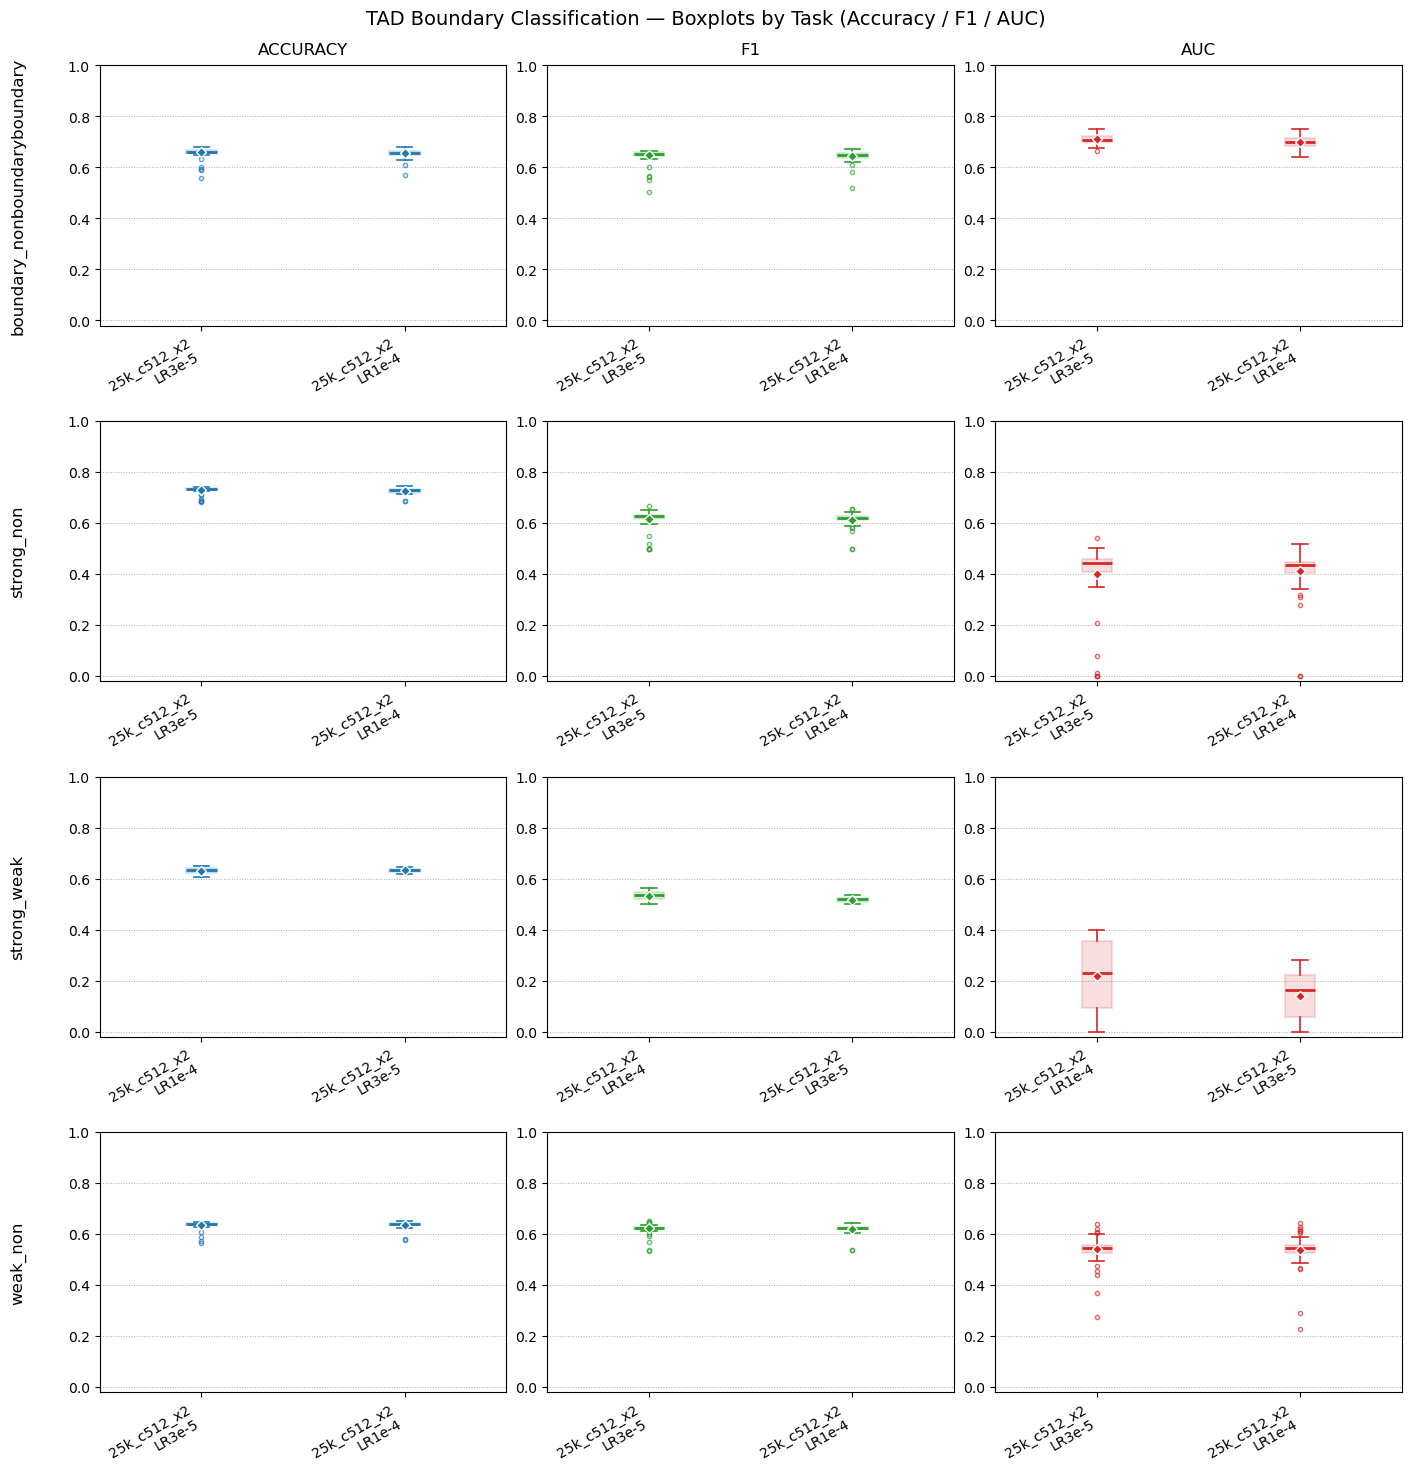

In [14]:
df, summary = make_ft_report("./TAD/TAD_boundary_ft5cells/classification",outfile="figs/ft5cells_boxgrid.png")